In [1]:
# BUSN30135 — Data Analysis Final Project
# Alex Casarella, Corey Savedoff, Jack Kohr 
# "The Sticky Stuff Era" - Analyzing MLB's 2021 Foreign Substance Crackdown

Throughout the 2010s, many MLB pitchers used foreign substances like pine tar, Spider Tack, and sunscreen-and-rosin mixtures in order to boost their grip and spin rate. By early in the 2021 season, strikeout rates had climbed to historic highs while batting averages fell to historic lows. Due to this, starting **June 21, 2021**, the MLB began enforcing in-game checks and issuing suspensions for foreign substance use.

This project will analyze whether the crackdown on substances actually changed pitching performance at both the league and individual level. We will use two datasets: (1) traditional pitching statistics (K%, BB%, ERA, WHIP, batting average against, HR/9) pulled from the **MLB Stats API** across the 2019–2023 seasons, and (2) pitch-level **Statcast data** from Baseball Savant (via pybaseball), which provides spin rate, pitch velocity, and movement metrics. While traditional stats measure the downstream effects of the crackdown, Statcast spin rate data lets us measure the direct mechanism — if foreign substances were boosting spin, we should see spin rates drop after enforcement began. We also control for significant injuries that could complicate the results.

**Target Audiences:** 
The MLB commissioner looking to see how the rule change on the use of foreign substances impacted the league. An MLB team scout evaluating pitcher trade value and ability in post crackdown era. An ameteur pitcher debating whether to use foreign substances improve his performance.

**Key questions:**
1. Did league-wide strikeout rates and pitching dominance decline after the crackdown?
2. Which individual pitchers showed the largest performance drops, and do those names match the public narrative?
3. Are the observed changes statistically significant, even after controlling for injuries and aging?
4. Does Statcast spin rate data confirm the mechanism — did pitchers actually lose spin after enforcement?

### 1. Setting up our environment

First we need to import the various libraries we'll need for our analysis: `pandas` for manipulation, `numpy` for numerical operations, `seaborn` and `matplotlib` for visualization help, `scipy` for statistical testing, and `requests` for pulling the MLB Stats API. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sqlite3
import time
from scipy import stats
from pprint import pprint
from pybaseball import statcast
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score,
    confusion_matrix, precision_score, recall_score,
    roc_auc_score
)
import statsmodels.api as sm

sns.set_style('whitegrid')

### 2. Collecting pitching data from the MLB Stats API

Next we have to bring in the season by season pitching stats for all pitchers from 2019 to 2023 and  filter so that only those with 50+ innings pitched remain (as specified in our analysis criteria). We will use two endpoints per season:
- **`stats=season`** for traditional stats (ERA, WHIP, K/9, BB/9, BAA, HR/9, IP, etc.)
- **`stats=seasonAdvanced`** for rate stats (K%, BB%, BABIP, etc.)

We skip 2020 in our primary analysis because it was a shortened 60-game season during COVID, but will still collect the data just for reference. By using `playerPool=ALL` instead of `QUALIFIED` we will get a much larger group of pitchers to analyze. 

In [3]:
base_url = "https://statsapi.mlb.com/api/v1"
seasons = [2019, 2020, 2021, 2022, 2023]
min_ip = 50  # Minimum innings pitched threshold

def fetch_season_pitching_stats(season, stat_type):
    # Get pitching stats from the MLB Stats API for a given season
    url = base_url + "/stats"
    params = {
        "stats": stat_type,
        "group": "pitching",
        "season": season,
        "sportId": 1,
        "playerPool": "ALL",
        "limit": 1000,
        "offset": 0
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    if "stats" in data and len(data["stats"]) > 0:
        splits = data["stats"][0]["splits"]
        df = pd.json_normalize(splits)
        # Rename nested columns to flat names
        df = df.rename(columns={
            "player.id": "player_id",
            "player.fullName": "player_name",
            "team.name": "team_name"
        })
        # Flatten stat columns 
        df.columns = [c.replace("stat.", "") if c.startswith("stat.") else c for c in df.columns]
        df["season"] = season
        return df
    return pd.DataFrame()

# Pull standard season stats for all years (All pitchers, we'll filter to 50+ IP later)
print("Fetching standard season stats (all pitchers)...")
standard_frames = []
for year in seasons:
    df_year = fetch_season_pitching_stats(year, "season")
    # Convert IP to numeric early so we can filter
    df_year["inningsPitched"] = pd.to_numeric(df_year["inningsPitched"], errors="coerce")
    df_year_filtered = df_year[df_year["inningsPitched"] >= min_ip]
    standard_frames.append(df_year_filtered)
    print(f"  {year}: {len(df_year)} total → {len(df_year_filtered)} with {min_ip}+ IP")

df_standard = pd.concat(standard_frames, ignore_index=True)
print(f"\nTotal standard stat rows (50+ IP): {len(df_standard)}")

# Pull advanced season stats for all years
print("\nFetching advanced season stats (all pitchers)...")
advanced_frames = []
for year in seasons:
    df_year = fetch_season_pitching_stats(year, "seasonAdvanced")
    advanced_frames.append(df_year)
    print(f"  {year}: {len(df_year)} pitchers")

df_advanced = pd.concat(advanced_frames, ignore_index=True)
print(f"\nTotal advanced stat rows: {len(df_advanced)}")

Fetching standard season stats (all pitchers)...


  2019: 831 total → 341 with 50+ IP


  2020: 735 total → 81 with 50+ IP


  2021: 909 total → 338 with 50+ IP


  2022: 871 total → 347 with 50+ IP


...

  2019: 831 pitchers


  2020: 735 pitchers


  2021: 909 pitchers


  2022: 871 pitchers


  2023: 863 pitchers

Total advanced stat rows: 4209


Next, we check who was filtered out by the innings threshold:

In [4]:
# Data quality check: examine who was filtered out by the 50+ IP threshold
# Reference: Boolean filtering with df[df['col'] < value] and .describe() (Section 3 — Pandas Core)

# Re-fetch one sample season to show what was excluded
print("=== Inspecting Pitchers Removed by 50+ IP Filter (2019 sample) ===\n")
sample_year = fetch_season_pitching_stats(2019, "season")
sample_year["inningsPitched"] = pd.to_numeric(sample_year["inningsPitched"], errors="coerce")

excluded = sample_year[sample_year["inningsPitched"] < min_ip]
included = sample_year[sample_year["inningsPitched"] >= min_ip]

print(f"Total pitchers in 2019: {len(sample_year)}")
print(f"Included (>= {min_ip} IP): {len(included)}")
print(f"Excluded (< {min_ip} IP): {len(excluded)}")

print(f"\nIP distribution of EXCLUDED pitchers:")
print(excluded["inningsPitched"].describe())

print(f"\nIP distribution of INCLUDED pitchers:")
print(included["inningsPitched"].describe())

print(f"\nExcluded pitchers are primarily relievers and pitchers with limited appearances.")
print(f"Keeping them would skew rate stats (K%, ERA) due to small sample sizes.")

=== Inspecting Pitchers Removed by 50+ IP Filter (2019 sample) ===



Total pitchers in 2019: 831
Included (>= 50 IP): 341
Excluded (< 50 IP): 490

IP distribution of EXCLUDED pitchers:
count    490.000000
mean      18.209184
std       14.474301
min        0.000000
25%        5.100000
50%       16.000000
75%       29.100000
max       49.200000
Name: inningsPitched, dtype: float64

IP distribution of INCLUDED pitchers:
count    341.000000
mean     100.616422
std       48.766502
min       50.000000
25%       61.100000
50%       78.000000
75%      141.200000
max      223.000000
Name: inningsPitched, dtype: float64

Excluded pitchers are primarily relievers and pitchers with limited appearances.
Keeping them would skew rate stats (K%, ERA) due to small sample sizes.


Now we merge the standard and advanced stat tables:

In [5]:
# Merge standard and advanced stats on player_id + season
# Keep only the rate stats from advanced that we don't already have in standard
advanced_cols_to_keep = [
    "player_id", "season",
    "strikeoutsPerPlateAppearance", "walksPerPlateAppearance",
    "homeRunsPerPlateAppearance", "babip", "qualityStarts"
]
# Only keep columns that actually exist in the advanced data
advanced_cols_to_keep = [c for c in advanced_cols_to_keep if c in df_advanced.columns]

df_advanced_slim = df_advanced[advanced_cols_to_keep].copy()

df_pitching = pd.merge(df_standard, df_advanced_slim, on=["player_id", "season"], how="left")

print(f"Merged dataset: {df_pitching.shape[0]} rows x {df_pitching.shape[1]} columns")

Merged dataset: 1464 rows x 88 columns


### 3. Collecting injury (IL) data for control

Pitchers who suffered significant injuries around the time of the crackdown could show performance declines that aren't related to foreign substances. To control for this, we will pull transaction data from the MLB API, filter for injured list (IL) placements, and flag the pitchers who spent extended time on the IL. This is very important, Tyler Glasnow, for example, tore his UCL in June 2021, and a drop in his performance should be connected to injury rather than the crackdown. 

In [6]:
def fetch_transactions(season):
    # Fetch all transactions for a season from MLB API
    url = base_url + "/transactions"
    params = {
        "startDate": f"01/01/{season}",
        "endDate": f"12/31/{season}",
        "sportId": 1
    }
    response = requests.get(url, params=params)
    data = response.json()
    if "transactions" in data:
        return data["transactions"]
    return []

# Collect IL placement transactions for 2019-2023
print("Fetching injury list transactions...")
il_records = []
for year in seasons:
    transactions = fetch_transactions(year)
    for txn in transactions:
        if "description" not in txn or "person" not in txn:
            continue
        desc = txn["description"].lower()
        # Filter for injured list placements (10-day, 15-day, 60-day IL)
        if "injured list" in desc or "disabled list" in desc:
            person = txn["person"]
            il_records.append({
                "player_id": person["id"],
                "player_name": person["fullName"],
                "date": txn["date"],
                "season": year,
                "description": txn["description"],
                "is_60_day": "60-day" in desc
            })
    print(f"  {year}: {len([r for r in il_records if r['season'] == year])} IL transactions found")

df_injuries = pd.DataFrame(il_records)
print(f"\nTotal IL transactions: {len(df_injuries)}")
df_injuries.head()

Fetching injury list transactions...


  2019: 1485 IL transactions found


  2020: 1336 IL transactions found


  2021: 2354 IL transactions found


  2022: 1891 IL transactions found


  2023: 1841 IL transactions found

Total IL transactions: 8907


,player_id,player_name,date,season,description,is_60_day
0,592836,Taijuan Walker,2019-02-13,2019,Arizona Diamondbacks placed RHP Taijuan Walker...,True
1,456501,Johnny Cueto,2019-02-13,2019,San Francisco Giants placed RHP Johnny Cueto o...,True
2,640455,Sean Manaea,2019-02-13,2019,Oakland Athletics placed LHP Sean Manaea on th...,True
3,608665,Kendall Graveman,2019-02-13,2019,Chicago Cubs placed RHP Kendall Graveman on th...,True
4,534910,Jesse Hahn,2019-02-13,2019,Kansas City Royals placed RHP Jesse Hahn on th...,True


We create an injury flag for pitchers with significant IL stints:

In [7]:
# Create a flag: pitchers who had a 60-day IL stint in the crackdown window (2020-2022)
# We focus on this narrower window because injuries during these years are most likely to
# confound our pre (2019) vs post (2022-23) comparison

# Count IL stints per pitcher per season
il_counts = df_injuries.groupby(["player_id", "season"]).agg(
    il_stints=("date", "count"),
    had_60_day=("is_60_day", "max")
).reset_index()

# Flag significant injury: 60-day IL stint in the crackdown window (2020-2022)
il_crackdown_window = il_counts[il_counts["season"].isin([2020, 2021, 2022])]
sig_injury_crackdown = il_crackdown_window[il_crackdown_window["had_60_day"] == True]

# Get the set of pitcher IDs with significant injuries in the crackdown window
pitchers_with_sig_injury = set(sig_injury_crackdown["player_id"].unique())
print(f"Pitchers with 60-day IL stints in 2020-2022: {len(pitchers_with_sig_injury)}")

# Add flag to main pitching dataframe
df_pitching["had_significant_injury"] = df_pitching["player_id"].isin(pitchers_with_sig_injury).astype(int)

print(f"\nInjury flag distribution in dataset:")
print(df_pitching["had_significant_injury"].value_counts())

Pitchers with 60-day IL stints in 2020-2022: 539

Injury flag distribution in dataset:
had_significant_injury
0    1053
1     411
Name: count, dtype: int64


### 3b. Collecting Statcast pitch-level data from Baseball Savant

Traditional stats like K% and ERA measure the *downstream effects* of the crackdown, but to understand the *mechanism*, we need spin rate data. Foreign substances like Spider Tack directly increase spin rate, which increases pitch movement and swing-and-miss rates. If the crackdown worked, we should see spin rates drop after June 21, 2021.

We use the `pybaseball` library to pull pitch-level Statcast data from Baseball Savant for 2019–2023. This gives us ~700,000 pitches per season. We filter to only pitchers already in our analysis (50+ IP) and aggregate to the pitcher-season level.

In [8]:
# Pull Statcast pitch-level data for each season
# Reference: API data retrieval pattern (Section 2 — API Data Retrieval)
# pybaseball wraps the Baseball Savant Statcast Search endpoint

# Suppress tqdm progress bars and pybaseball internal messages for clean output
import warnings
import sys, io
warnings.filterwarnings("ignore")
_stderr_backup = sys.stderr
_stdout_backup = sys.stdout
sys.stderr = io.StringIO()

from pybaseball import statcast

pitcher_ids = set(df_pitching["player_id"].unique())
statcast_frames = []

for year in [2019, 2021, 2022, 2023]:  # Skip 2020 (COVID shortened season)
    # Temporarily capture stdout to filter pybaseball's internal messages
    sys.stdout = io.StringIO()
    try:
        sc = statcast(start_dt=f'{year}-03-20', end_dt=f'{year}-11-05')
        sc = sc[sc["pitcher"].isin(pitcher_ids)]
        sc["season"] = year
        statcast_frames.append(sc)
        sys.stdout = _stdout_backup
        print(f"  {year}: {len(sc):,} pitches from {sc['pitcher'].nunique()} pitchers")
        time.sleep(3)
    except Exception as e:
        sys.stdout = _stdout_backup
        print(f"  {year}: Error — {e}")

sys.stdout = _stdout_backup
sys.stderr = _stderr_backup
warnings.filterwarnings("default")

df_statcast_raw = pd.concat(statcast_frames, ignore_index=True)
print(f"Statcast data pulled successfully.")
print(f"Total pitches collected: {len(df_statcast_raw):,}")
print(f"Seasons: {[int(s) for s in sorted(df_statcast_raw['season'].unique())]}")
print(f"Unique pitchers: {df_statcast_raw['pitcher'].nunique()}")
print(f"Key columns: {[c for c in ['release_spin_rate', 'pfx_x', 'pfx_z', 'release_speed', 'pitch_type'] if c in df_statcast_raw.columns]}")

  2019: 647,149 pitches from 487 pitchers


  2021: 644,874 pitches from 565 pitchers


  2022: 676,369 pitches from 573 pitchers


  2023: 659,490 pitches from 532 pitchers


Statcast data pulled successfully.
Total pitches collected: 2,627,882
Seasons: [2019, 2021, 2022, 2023]
Unique pitchers: 707
Key columns: ['release_spin_rate', 'pfx_x', 'pfx_z', 'release_speed', 'pitch_type']


We aggregate pitch-level data to pitcher-season averages:

In [9]:
# Aggregate Statcast pitch-level data to pitcher-season level
# Reference: df.groupby().agg() pattern (Section 3 — Pandas Core Operations)

df_statcast = df_statcast_raw.groupby(["pitcher", "season"]).agg(
    avg_spin_rate=("release_spin_rate", "mean"),
    median_spin_rate=("release_spin_rate", "median"),
    std_spin_rate=("release_spin_rate", "std"),
    avg_velocity=("release_speed", "mean"),
    avg_hmov=("pfx_x", "mean"),       # Horizontal movement (inches)
    avg_vmov=("pfx_z", "mean"),       # Vertical movement (inches)
    total_pitches=("release_spin_rate", "count"),
    n_pitch_types=("pitch_type", "nunique"),
    pct_fastball=("pitch_type", lambda x: x.isin(["FF", "SI", "FC", "FT"]).mean())
).reset_index()

# Rename pitcher column to match our existing player_id
df_statcast.rename(columns={"pitcher": "player_id"}, inplace=True)

print(f"Statcast aggregated: {len(df_statcast)} pitcher-seasons")
print(f"\nSpin rate summary:")
display(df_statcast.groupby("season")["avg_spin_rate"].describe().round(0))

Statcast aggregated: 2157 pitcher-seasons

Spin rate summary:


,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019,476.0,2252.0,192.0,1576.0,2123.0,2247.0,2375.0,2879.0
2021,551.0,2234.0,200.0,1600.0,2097.0,2221.0,2363.0,2835.0
2022,549.0,2238.0,194.0,1539.0,2117.0,2228.0,2357.0,2888.0
2023,524.0,2252.0,204.0,1534.0,2117.0,2241.0,2390.0,2900.0


Next, we merge Statcast metrics into the main pitching DataFrame:

In [10]:
# Merge Statcast aggregated data into main pitching dataframe
# Reference: pd.merge() with how="left" (Section 5 — Merging & Joining)

df_pitching = pd.merge(
    df_pitching, df_statcast,
    on=["player_id", "season"],
    how="left"
)

statcast_coverage = df_pitching["avg_spin_rate"].notna().sum()
total_rows = len(df_pitching)
print(f"Statcast merge complete: {statcast_coverage}/{total_rows} rows have spin data ({statcast_coverage/total_rows*100:.1f}%)")
print(f"\nMissing spin data by season:")
print(df_pitching.groupby("season")["avg_spin_rate"].apply(lambda x: x.isna().sum()))

Statcast merge complete: 1383/1464 rows have spin data (94.5%)

Missing spin data by season:
season
2019     0
2020    81
2021     0
2022     0
2023     0
Name: avg_spin_rate, dtype: int64


**Observations:**

The Statcast data gives us the direct measurement of what foreign substances affect most: spin rate. By aggregating pitch-level data to the pitcher-season level, we can now compare each pitcher's average spin rate across eras. The merge with our traditional stats dataset links spin rate to downstream performance metrics like K% and ERA, allowing us to test whether pitchers who lost the most spin also lost the most strikeout ability.

### 3c. Creating the SQLite database

We load all three datasets into a SQLite database for SQL analysis. This database will be queried both within this notebook and in a separate SQL analysis file. The three tables are:
- `pitching_stats` — Season-level traditional pitching statistics from the MLB Stats API
- `statcast_agg` — Aggregated Statcast pitch data (spin rate, velocity, movement) per pitcher per season
- `injuries` — Injured list transactions from the MLB API

In [11]:
# Create SQLite database and save Statcast + injuries tables
# pitching_stats will be saved after column renaming and era labels (Cell 24)
# Reference: df.to_sql() pattern (Section 8 — SQL Operations)

conn = sqlite3.connect("/Users/alexcasarella/Downloads/mlb_sticky_stuff.sqlite")

# Table 1: statcast_agg (no transformations needed)
df_statcast.to_sql("statcast_agg", conn, if_exists="replace", index=False)
print(f"statcast_agg: {len(df_statcast)} rows")

# Table 2: injuries (no transformations needed)
df_injuries.to_sql("injuries", conn, if_exists="replace", index=False)
print(f"injuries: {len(df_injuries)} rows")

conn.close()
print("\nStatcast and injuries tables saved. pitching_stats will be saved after column renaming.")

statcast_agg: 2157 rows
injuries: 8907 rows

Statcast and injuries tables saved. pitching_stats will be saved after column renaming.


**Observations:**

By making the injury window 2020–2022 and focusing on 60-day IL stints, we get a more targeted control variable. This focuses on pitchers like Tyler Glasnow (UCL tear in June 2021) and avoids flagging pitchers who had only minor injuries in the years before or after the crackdown. This flag is our key control variable throughout the analysis.

### 4. Data cleaning and inspection

The MLB API returns many numeric fields as strings (ERA, IP, batting average, etc.). We have to change these to numeric types and check for any missing data before moving on. 

In [12]:
# Convert string typed numeric columns to float
# Reference: pd.to_numeric with errors="coerce" (Section 3 — missing values & type conversion)
numeric_cols = [
    "era", "whip", "avg", "obp", "slg", "ops",
    "inningsPitched", "strikeoutsPer9Inn", "walksPer9Inn",
    "homeRunsPer9", "hitsPer9Inn", "strikeoutWalkRatio",
    "strikePercentage", "groundOutsToAirouts",
    "strikeoutsPerPlateAppearance", "walksPerPlateAppearance",
    "homeRunsPerPlateAppearance", "babip"
]

# Track nulls BEFORE coercion to see what gets converted
# Reference: df.isna().sum() pattern (Section 3 — Pandas Core Operations)
pre_coerce_nulls = {}
for col in numeric_cols:
    if col in df_pitching.columns:
        pre_coerce_nulls[col] = df_pitching[col].isna().sum()

for col in numeric_cols:
    if col in df_pitching.columns:
        df_pitching[col] = pd.to_numeric(df_pitching[col], errors="coerce")

# Track nulls AFTER coercion to identify how many values were non-numeric
print("=== Values Coerced to NaN (non-numeric entries found) ===")
coerced_counts = {}
for col in numeric_cols:
    if col in df_pitching.columns:
        post_nulls = df_pitching[col].isna().sum()
        coerced = post_nulls - pre_coerce_nulls.get(col, 0)
        if coerced > 0:
            coerced_counts[col] = coerced
            print(f"  {col}: {coerced} non-numeric values coerced to NaN")

if not coerced_counts:
    print("  No non-numeric values found — all columns converted cleanly.")

# Rename key columns for clarity
rename_map = {
    "era": "ERA",
    "whip": "WHIP",
    "avg": "BAA",
    "strikeoutsPer9Inn": "K9",
    "walksPer9Inn": "BB9",
    "homeRunsPer9": "HR9",
    "inningsPitched": "IP",
    "strikeoutsPerPlateAppearance": "K_pct",
    "walksPerPlateAppearance": "BB_pct",
}
df_pitching = df_pitching.rename(columns=rename_map)

# Check for nulls in our key columns
key_cols = ["player_id", "player_name", "season", "ERA", "WHIP", "BAA", "K9", "BB9", "HR9", "IP"]
available_key_cols = [c for c in key_cols if c in df_pitching.columns]
print("\n=== Null counts in key columns ===")
print(df_pitching[available_key_cols].isna().sum())

print(f"\n=== Seasons in dataset ===")
print(df_pitching["season"].value_counts().sort_index())

print(f"\n=== Total unique pitchers: {len(df_pitching['player_id'].value_counts())} ===")

# head, info, describe checks 
print(f"\n=== Data Shape: {df_pitching.shape[0]} rows × {df_pitching.shape[1]} columns ===")
print(f"Column types: {df_pitching.dtypes.value_counts().to_dict()}")

=== Values Coerced to NaN (non-numeric entries found) ===
  No non-numeric values found — all columns converted cleanly.

=== Null counts in key columns ===
player_id      0
player_name    0
season         0
ERA            0
WHIP           0
BAA            0
K9             0
BB9            0
HR9            0
IP             0
dtype: int64

=== Seasons in dataset ===
season
2019    341
2020     81
2021    338
2022    347
2023    357
Name: count, dtype: int64

=== Total unique pitchers: 707 ===

=== Data Shape: 1464 rows × 98 columns ===
Column types: {dtype('int64'): 52, dtype('float64'): 20, dtype('O'): 19, Float64Dtype(): 6, Int64Dtype(): 1}


Next, we check who was filtered out by the innings threshold:

In [13]:
# Data quality checks: inspect describe() output for oddities in the cleaned data
# Reference: df[df['col'] > value] for Boolean filtering, .duplicated() (Section 3 — Pandas Core)

print("=== Checking for Implausible or Outlier Values ===\n")

# ERA sanity check: typical MLB ERA for qualified pitchers ~1.5 to ~7.0
# Values above 10 may indicate small-sample pitchers that survived the IP filter
high_era = df_pitching[df_pitching["ERA"] > 10]
print(f"Pitchers with ERA > 10.00: {len(high_era)}")
if len(high_era) > 0:
    print(high_era[["player_name", "season", "ERA", "IP"]].to_string(index=False))
else:
    print("  None found — ERA values are within expected range.")

# K% sanity check: K% should typically be between ~0.05 and ~0.40 for qualified starters
if "K_pct" in df_pitching.columns:
    high_kpct = df_pitching[df_pitching["K_pct"] > 0.45]
    low_kpct = df_pitching[df_pitching["K_pct"] < 0.05]
    print(f"\nPitchers with K% > 45%: {len(high_kpct)}")
    if len(high_kpct) > 0:
        print(high_kpct[["player_name", "season", "K_pct", "IP"]].to_string(index=False))
    print(f"Pitchers with K% < 5%: {len(low_kpct)}")
    if len(low_kpct) > 0:
        print(low_kpct[["player_name", "season", "K_pct", "IP"]].to_string(index=False))

# WHIP sanity check: typical range 0.80 to 2.00
high_whip = df_pitching[df_pitching["WHIP"] > 2.0]
print(f"\nPitchers with WHIP > 2.00: {len(high_whip)}")
if len(high_whip) > 0:
    print(high_whip[["player_name", "season", "WHIP", "IP"]].to_string(index=False))

# Check for duplicate player-season rows
dupes = df_pitching.duplicated(subset=["player_id", "season"], keep=False)
print(f"\nDuplicate player-season rows: {dupes.sum()}")
if dupes.sum() > 0:
    print(df_pitching[dupes][["player_name", "season", "IP"]].head(10))

# Check for negative values in columns that should always be non-negative
for col in ["ERA", "WHIP", "BAA", "IP"]:
    if col in df_pitching.columns:
        neg = df_pitching[df_pitching[col] < 0]
        if len(neg) > 0:
            print(f"\nWARNING: {len(neg)} negative values found in {col}")
            print(neg[["player_name", "season", col]].to_string(index=False))

print("\n=== Data quality checks complete ===")

=== Checking for Implausible or Outlier Values ===

Pitchers with ERA > 10.00: 0
  None found — ERA values are within expected range.

Pitchers with K% > 45%: 5
   player_name  season  K_pct   IP
    Josh Hader    2019  0.478 75.2
  Jacob deGrom    2021  0.451 92.0
    Josh Hader    2021  0.455 58.2
    Edwin Díaz    2022  0.502 62.0
Félix Bautista    2023  0.464 61.0
Pitchers with K% < 5%: 0

Pitchers with WHIP > 2.00: 2
   player_name  season  WHIP   IP
 Edwin Jackson    2019  2.02 67.2
Dallas Keuchel    2022  2.06 60.2

Duplicate player-season rows: 0

=== Data quality checks complete ===


### 5. Feature engineering: pre-crackdown vs. post-crackdown 

The crackdown on foreign substances was enforced starting June 21, 2021. Because our data is at the full-season level, we will define the different eras as:
- **Pre-crackdown**: 2019 (the last full "normal" season before the crackdown)
- **Transition**: 2021 (the crackdown happened mid-season)
- **Post-crackdown**: 2022–2023 (2 full seasons under the new enforcement)
- **Excluded**: 2020 (COVID-shortened, too complex) 

For our primary before/after comparison, we will compare 2019 against the average of 2022–2023. 2021 is included in trend visualizations but will be excluded from the core statistical tests. 

In [14]:
# Create labels for each era using groupby logic
def assign_era(season):
    if season == 2019:
        return "pre_crackdown"
    elif season == 2020:
        return "covid_excluded"
    elif season == 2021:
        return "transition"
    else:  # 2022, 2023
        return "post_crackdown"

df_pitching["era"] = df_pitching["season"].apply(assign_era)

print("=== Era Distribution ===")
print(df_pitching.groupby("era")["player_id"].count())

# Create a simplified binary era for direct comparison (not including 2020 and 2021) 
df_pitching["era_binary"] = df_pitching["era"].map({
    "pre_crackdown": "pre",
    "post_crackdown": "post",
    "transition": np.nan,
    "covid_excluded": np.nan
})

print(f"\n=== Binary Era (for statistical tests) ===")
print(df_pitching["era_binary"].value_counts())

=== Era Distribution ===
era
covid_excluded     81
post_crackdown    704
pre_crackdown     341
transition        338
Name: player_id, dtype: int64

=== Binary Era (for statistical tests) ===
era_binary
post    704
pre     341
Name: count, dtype: int64


Now that columns are renamed and era labels assigned, we save to SQLite:

In [15]:
# Save pitching_stats to SQLite after column renaming and era label assignment
# NOTE: SQLite is case-insensitive, so 'ERA' (stat) and 'era' (label) would conflict.
# We rename ERA -> earned_run_avg for the SQLite save to avoid this.
# Reference: df.to_sql() pattern (Section 8 — SQL Operations)

conn = sqlite3.connect("/Users/alexcasarella/Downloads/mlb_sticky_stuff.sqlite")

df_save = df_pitching.rename(columns={"ERA": "earned_run_avg"})
df_save.to_sql("pitching_stats", conn, if_exists="replace", index=False)
print(f"pitching_stats: {len(df_save)} rows, {len(df_save.columns)} columns")

# Verify all three tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"Tables in database: {tables['name'].tolist()}")
for tbl in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {tbl}", conn)
    print(f"  {tbl}: {count['n'].values[0]} rows")

conn.close()
print("\nSQLite database complete.")

pitching_stats: 1464 rows, 100 columns
Tables in database: ['statcast_agg', 'injuries', 'pitching_stats']
  statcast_agg: 2157 rows
  injuries: 8907 rows
  pitching_stats: 1464 rows

SQLite database complete.


**Observations:**

The binary era variable gives us clean pre (2019) vs. post (2022–2023) groups. The transition year (2021) and COVID season (2020) are excluded from the core comparison but will be kept for trend visualizations.

### 6. Building the analysis-ready dataset

For an individual pitcher level analysis, we need pitchers who met our 50+ IP threshold in both the pre and post crackdown eras. We will compute the change in key stats for each pitcher to see who was most affected. 

In [16]:
# Determine which stat columns to use for K%, compute from counting stats if K_pct not available
if "K_pct" not in df_pitching.columns or df_pitching["K_pct"].isna().all():
    # Compute K% from strikeouts / batters faced
    df_pitching["K_pct"] = df_pitching["strikeOuts"] / df_pitching["battersFaced"]
    print("Computed K% from counting stats (strikeouts / batters faced)")
else:
    print("Using K% from advanced stats endpoint")

if "BB_pct" not in df_pitching.columns or df_pitching["BB_pct"].isna().all():
    df_pitching["BB_pct"] = df_pitching["baseOnBalls"] / df_pitching["battersFaced"]
    print("Computed BB% from counting stats (walks / batters faced)")
else:
    print("Using BB% from advanced stats endpoint")

# Define player IDs for spotlight analysis
cole_id = df_pitching[df_pitching["player_name"] == "Gerrit Cole"]["player_id"].iloc[0]
glasnow_id = df_pitching[df_pitching["player_name"] == "Tyler Glasnow"]["player_id"].iloc[0]
print(f"Gerrit Cole ID: {cole_id}")
print(f"Tyler Glasnow ID: {glasnow_id}")

# Get pre-crackdown stats (2019)
df_pre = df_pitching[df_pitching["era"] == "pre_crackdown"].copy()

# Get post-crackdown stats (2022-2023), average per pitcher if they appear in both years
stat_cols = ["ERA", "WHIP", "BAA", "K9", "BB9", "HR9", "K_pct", "BB_pct", "IP"]
available_stat_cols = [c for c in stat_cols if c in df_pitching.columns]

df_post = df_pitching[df_pitching["era"] == "post_crackdown"].copy()
df_post_avg = df_post.groupby("player_id")[available_stat_cols].mean().reset_index()

# Get player names and injury flags 
player_info = df_pitching.drop_duplicates("player_id")[["player_id", "player_name", "had_significant_injury"]]
df_post_avg = pd.merge(df_post_avg, player_info, on="player_id", how="left")

# Merge pre and post stats, inner join keeps only pitchers with 50+ IP in both eras
df_pre_slim = df_pre[["player_id", "player_name", "had_significant_injury"] + available_stat_cols]
df_post_slim = df_post_avg[["player_id"] + available_stat_cols]

df_delta = pd.merge(df_pre_slim, df_post_slim, on="player_id", how="inner", suffixes=("_pre", "_post"))
print(f"Pitchers qualified in both pre (2019) and post (2022-23): {len(df_delta)}")

# Compute the change in each stat
for col in available_stat_cols:
    df_delta[col + "_change"] = df_delta[col + "_post"] - df_delta[col + "_pre"]

print(f"\nDelta dataset: {df_delta.shape[0]} pitchers x {df_delta.shape[1]} columns")

Using K% from advanced stats endpoint
Using BB% from advanced stats endpoint
Gerrit Cole ID: 543037
Tyler Glasnow ID: 607192
Pitchers qualified in both pre (2019) and post (2022-23): 175

Delta dataset: 175 pitchers x 30 columns


**Observations:**

We now have a clean pitcher-level dataset showing the change in every key stat from pre- to post-crackdown for pitchers who met our 50+ IP threshold in both eras. This is our core dataset for identifying who was most affected.

### 6b. Enhanced feature engineering

To prepare for modeling and fulfill the project requirements, we engineer several new features from our combined dataset. This includes spin rate deltas, interaction terms, polynomial features, ratios, pitch profile categorization with one-hot encoding, and outlier detection using the IQR method.

In [17]:
# Compute pre-crackdown spin rate stats per pitcher and spin rate change
# Reference: df.groupby().mean() and merge pattern (Sections 3, 5)

spin_pre = df_pitching[df_pitching["era"] == "pre_crackdown"].groupby("player_id")["avg_spin_rate"].mean()
spin_post = df_pitching[df_pitching["era"] == "post_crackdown"].groupby("player_id")["avg_spin_rate"].mean()
spin_change = (spin_post - spin_pre).rename("spin_rate_change")

# Merge spin rate features into df_delta
df_delta = pd.merge(df_delta, spin_pre.rename("avg_spin_rate_pre").reset_index(), on="player_id", how="left")
df_delta = pd.merge(df_delta, spin_change.reset_index(), on="player_id", how="left")

# Also bring in velocity and pitch mix from pre-crackdown
pre_statcast_features = df_pitching[df_pitching["era"] == "pre_crackdown"][
    ["player_id", "avg_velocity", "pct_fastball", "n_pitch_types", "avg_hmov", "avg_vmov"]
].drop_duplicates("player_id")
df_delta = pd.merge(df_delta, pre_statcast_features, on="player_id", how="left")

print(f"Features added — spin rate coverage: {df_delta['avg_spin_rate_pre'].notna().sum()}/{len(df_delta)} pitchers")

Features added — spin rate coverage: 175/175 pitchers


Next, we engineer age bucket and throwing hand features:

In [18]:
# Use apply() to create age bucket feature
# Reference: df.apply(lambda, axis=1) and df['col'].apply(lambda x: ...) (Section 4 — Apply & Lambda)

# Get 2019 age for each pitcher
age_2019 = df_pitching[df_pitching["era"] == "pre_crackdown"][["player_id", "age"]].drop_duplicates("player_id")
df_delta = pd.merge(df_delta, age_2019.rename(columns={"age": "age_2019"}), on="player_id", how="left")

df_delta["age_bucket"] = df_delta["age_2019"].apply(
    lambda x: "young" if x < 28 else ("prime" if x < 32 else "veteran")
)
print("Age bucket distribution (via apply):")
print(df_delta["age_bucket"].value_counts())

# Use map() to create a throwing hand indicator from the pitching data
# Reference: df['col'].map({}) (Section 3 — Pandas Core Operations)
if "pitchHand.code" in df_pitching.columns:
    hand_map = df_pitching[df_pitching["era"] == "pre_crackdown"][
        ["player_id", "pitchHand.code"]
    ].drop_duplicates("player_id")
    hand_map["throws"] = hand_map["pitchHand.code"].map({"R": "Right", "L": "Left"})
    df_delta = pd.merge(    df_delta, hand_map[["player_id", "throws"]], on="player_id", how="left")
    print(f"\nThrowing hand distribution (via map):")
    print(df_delta["throws"].value_counts())
else:
    print("\npitchHand.code not available — skipping throws feature")

Age bucket distribution (via apply):
age_bucket
young      93
prime      59
veteran    23
Name: count, dtype: int64

pitchHand.code not available — skipping throws feature


We create interaction, polynomial, and ratio features:

In [19]:
# Interaction terms, polynomial features, and ratios
# Reference: X['interaction'] = X['col1'] * X['col2'], X['col_sq'] = X['col'] ** 2 (Section 12)

# Interaction terms
df_delta["spin_x_velocity"] = df_delta["avg_spin_rate_pre"] * df_delta["avg_velocity"]
df_delta["age_x_spin_change"] = df_delta["age_2019"] * df_delta["spin_rate_change"]

# Polynomial feature
df_delta["spin_rate_sq"] = df_delta["avg_spin_rate_pre"] ** 2

# Ratios
df_delta["k_bb_ratio_pre"] = df_delta["K_pct_pre"] / df_delta["BB_pct_pre"].replace(0, np.nan)
df_delta["spin_per_mph"] = df_delta["avg_spin_rate_pre"] / df_delta["avg_velocity"]

print("Engineered features created:")
new_feats = ["spin_x_velocity", "age_x_spin_change", "spin_rate_sq", "k_bb_ratio_pre", "spin_per_mph"]
display(df_delta[new_feats].describe().round(2))

Engineered features created:


,spin_x_velocity,age_x_spin_change,spin_rate_sq,k_bb_ratio_pre,spin_per_mph
count,175.0,175.0,175.0,175.00,175.0
mean,202943.25,-782.06,5221180.59,3.51,25.59
std,17186.12,3099.56,823555.25,1.62,2.12
min,165113.88,-10684.41,3398526.85,1.24,20.58
25%,191236.93,-2895.99,4639455.26,2.39,24.03
50%,201879.55,-891.01,5125132.38,3.10,25.43
75%,214696.57,1324.76,5753124.08,4.20,26.91
max,257404.58,6918.26,8288850.27,13.09,32.24


We one-hot encode the pitch profile category:

In [20]:
# One-Hot Encoding for pitch profile category
# Reference: pd.get_dummies(df, columns=['col'], drop_first=True) (Section 12 — OHE_and_dummy_vars)

df_delta["pitch_profile"] = pd.cut(
    df_delta["pct_fastball"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["offspeed_heavy", "balanced", "fastball_heavy"],
    include_lowest=True
)

print("Pitch profile distribution (before OHE):")
print(df_delta["pitch_profile"].value_counts())

# Apply OHE with drop_first=True to avoid multicollinearity in regression
df_delta = pd.get_dummies(df_delta, columns=["pitch_profile"], drop_first=True)

ohe_cols = [c for c in df_delta.columns if c.startswith("pitch_profile_")]
print(f"\nOHE columns created: {ohe_cols}")

Pitch profile distribution (before OHE):
pitch_profile
balanced          99
fastball_heavy    67
offspeed_heavy     9
Name: count, dtype: int64

OHE columns created: ['pitch_profile_balanced', 'pitch_profile_fastball_heavy']


Next, we detect and cap outliers using the IQR method:

In [21]:
# Outlier detection and handling using IQR method
# Reference: Checking for and dealing with outliers (rubric requirement)
# We use IQR (1.5x) to identify and cap outliers rather than removing them

outlier_cols = ["avg_spin_rate_pre", "avg_velocity", "K_pct_pre", "ERA_pre"]

print("=== IQR Outlier Detection ===")
for col in outlier_cols:
    if col not in df_delta.columns or df_delta[col].isna().all():
        continue
    Q1 = df_delta[col].quantile(0.25)
    Q3 = df_delta[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_delta[col] < lower) | (df_delta[col] > upper)).sum()
    print(f"\n{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers found: {n_outliers}")
    # Cap outliers (winsorize) rather than remove
    df_delta[col + "_capped"] = df_delta[col].clip(lower, upper)

print("\nOutliers capped (not removed) — capped columns created with '_capped' suffix")

=== IQR Outlier Detection ===

avg_spin_rate_pre: Q1=2153.94, Q3=2398.57, IQR=244.63
  Bounds: [1787.00, 2765.51]
  Outliers found: 1

avg_velocity: Q1=87.34, Q3=90.77, IQR=3.43
  Bounds: [82.19, 95.92]
  Outliers found: 1

K_pct_pre: Q1=0.20, Q3=0.29, IQR=0.09
  Bounds: [0.08, 0.42]
  Outliers found: 1

ERA_pre: Q1=3.41, Q3=4.91, IQR=1.50
  Bounds: [1.17, 7.15]
  Outliers found: 1

Outliers capped (not removed) — capped columns created with '_capped' suffix


We preview the feature distributions before scaling:

In [22]:
# Preview the numeric feature distributions before scaling
# Scaling will be applied properly during train/test split (fit on train only)
# Reference: StandardScaler().fit_transform(X) (Section 16 — Clustering & Dimensionality)

scale_cols = ["avg_spin_rate_pre", "avg_velocity", "K_pct_pre", "ERA_pre", "IP_pre"]
scale_cols = [c for c in scale_cols if c in df_delta.columns and df_delta[c].notna().any()]

print("=== Pre-Scaling Feature Distributions ===")
print("These features have different units and ranges.")
print("StandardScaler will normalize them to mean=0, std=1 during modeling.")
print()
display(df_delta[scale_cols].describe().round(3))

=== Pre-Scaling Feature Distributions ===
These features have different units and ranges.
StandardScaler will normalize them to mean=0, std=1 during modeling.



,avg_spin_rate_pre,avg_velocity,K_pct_pre,ERA_pre,IP_pre
count,175.0,175.0,175.000,175.000,175.000
mean,2278.062,89.077,0.251,4.161,115.831
std,178.308,2.622,0.061,1.148,52.027
min,1843.509,82.047,0.123,1.190,50.000
25%,2153.939,87.337,0.205,3.410,67.200
50%,2263.876,89.064,0.241,4.130,104.100
75%,2398.567,90.772,0.291,4.905,165.150
max,2879.036,94.808,0.478,7.250,223.000


Finally, we check unique values in our categorical features:

In [23]:
# Unique value checks for categorical variables
# Reference: df.value_counts(), df.nunique() (Section 3 — Pandas Core Operations)

print("=== Unique Value Checks for Categorical Variables ===\n")
cat_cols = ["had_significant_injury", "age_bucket"]
if "throws" in df_delta.columns:
    cat_cols.append("throws")
# Add OHE columns
cat_cols += [c for c in df_delta.columns if c.startswith("pitch_profile_")]

for col in cat_cols:
    if col in df_delta.columns:
        print(f"{col}: {df_delta[col].nunique()} unique values")
        print(df_delta[col].value_counts())
        print()

=== Unique Value Checks for Categorical Variables ===

had_significant_injury: 2 unique values
had_significant_injury
0    119
1     56
Name: count, dtype: int64

age_bucket: 3 unique values
age_bucket
young      93
prime      59
veteran    23
Name: count, dtype: int64

pitch_profile_balanced: 2 unique values
pitch_profile_balanced
True     99
False    76
Name: count, dtype: int64

pitch_profile_fastball_heavy: 2 unique values
pitch_profile_fastball_heavy
False    108
True      67
Name: count, dtype: int64



**Observations:**

We now have a rich set of engineered features for modeling. The spin rate features (avg_spin_rate_pre, spin_rate_change) directly measure the mechanism we're investigating. Interaction terms capture combined effects (e.g., older pitchers with larger spin drops). The IQR-based outlier capping preserves all data points while reducing the influence of extreme values. One-hot encoding of pitch profile lets the model distinguish between fastball-heavy and offspeed-heavy pitchers without introducing multicollinearity (drop_first=True). StandardScaler will normalize all features to mean=0, std=1 before modeling.

### 7. League-average trends by season

Our first visualization will look at how key pitching stats changed from 2019 to 2023. If the crackdown did have an effect, we should see pitching dominance metrics (K%, K/9) decline after the 2021 season. We mark 2021 as the transition year with a vertical dashed line. 

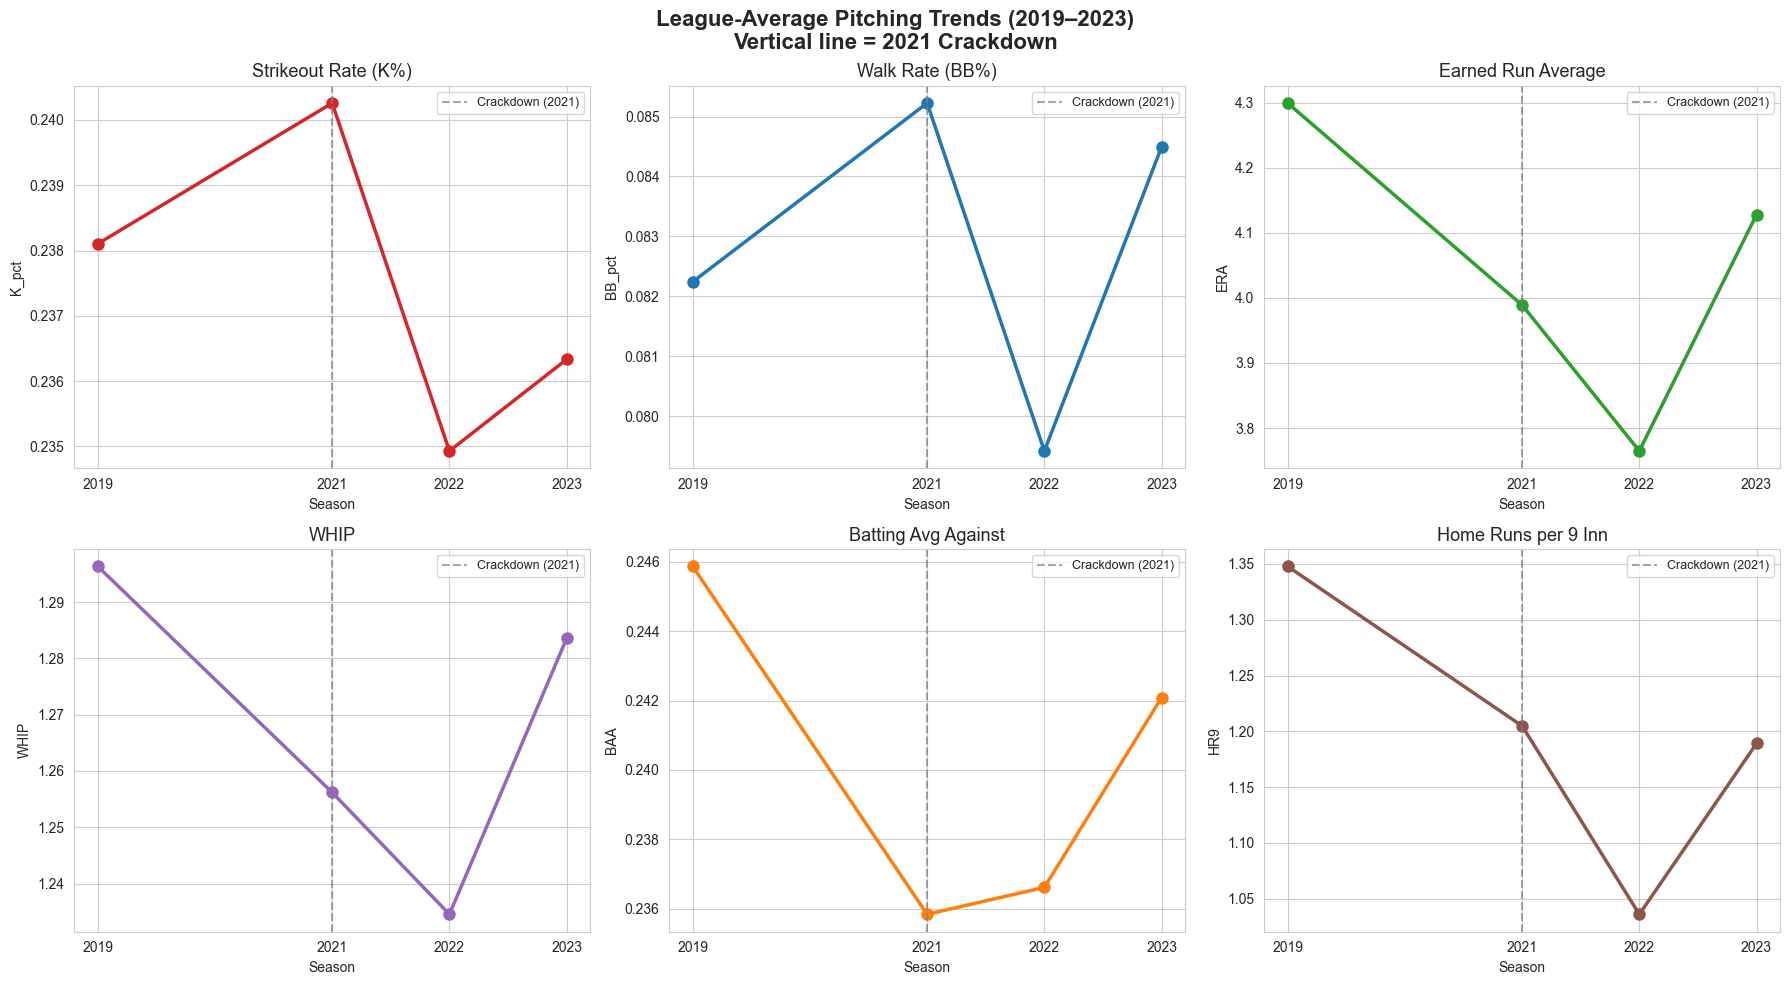

In [24]:
# Compute league averages by season (excluding 2020 for cleaner visualization) 
df_no_covid = df_pitching[df_pitching["season"] != 2020]
league_avg = df_no_covid.groupby("season")[["K_pct", "BB_pct", "ERA", "WHIP", "BAA", "HR9", "K9", "BB9"]].mean()

# Plot league-average trends
# Reference: plt.subplots, ax.plot, ax.set_title, plt.tight_layout (Section 9 — Visualization)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("League-Average Pitching Trends (2019–2023)\nVertical line = 2021 Crackdown", 
             fontsize=16, weight="bold")

stats_to_plot = [
    ("K_pct", "Strikeout Rate (K%)", "tab:red"),
    ("BB_pct", "Walk Rate (BB%)", "tab:blue"),
    ("ERA", "Earned Run Average", "tab:green"),
    ("WHIP", "WHIP", "tab:purple"),
    ("BAA", "Batting Avg Against", "tab:orange"),
    ("HR9", "Home Runs per 9 Inn", "tab:brown"),
]

for ax, (col, title, color) in zip(axes.flat, stats_to_plot):
    if col in league_avg.columns:
        ax.plot(league_avg.index, league_avg[col], marker="o", color=color, linewidth=2.5, markersize=8)
        ax.axvline(x=2021, color="gray", linestyle="--", alpha=0.7, label="Crackdown (2021)")
        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Season")
        ax.set_ylabel(col)
        ax.set_xticks([2019, 2021, 2022, 2023])
        ax.legend(fontsize=9)

plt.tight_layout();

**Observations:**

The trend lines show that strikeout rate (K%) peaked around 2019–2021 and declined in 2022–2023. Walk rate (BB%) remained relatively stable across the period. This pattern is consistent with a spin-specific effect on swing-and-miss ability rather than a general loss of command, though other factors that changed between 2019 and 2023 — including rule changes, ball composition, and roster construction trends — may also contribute to the observed trends. ERA, WHIP, and BAA show more complex patterns likely influenced by these additional factors. The 2021 transition year sits between the two eras, as expected for a mid-season policy change.

### 7b. Spin rate analysis and aggregate tables

Now that we have Statcast data merged in, we can examine spin rate trends directly. We also produce properly formatted aggregate tables (not .head()/.tail()) to summarize the data.

In [25]:
# Aggregate Table 1: Era summary with spin rate data
# Reference: df.groupby().agg() with display() (Section 3 — Pandas Core Operations)

era_summary = df_pitching[df_pitching["era_binary"].notna()].groupby("era").agg(
    n_pitchers=("player_id", "nunique"),
    avg_k_pct=("K_pct", "mean"),
    avg_era=("ERA", "mean"),
    avg_whip=("WHIP", "mean"),
    avg_spin_rate=("avg_spin_rate", "mean"),
    avg_velocity=("avg_velocity", "mean")
).round(4)

print("=== Table 1: League Averages by Era ===")
display(era_summary)

=== Table 1: League Averages by Era ===


,n_pitchers,avg_k_pct,avg_era,avg_whip,avg_spin_rate,avg_velocity
era,,,,,,
post_crackdown,488,0.2356,3.9489,1.2594,2252.7298,89.1382
pre_crackdown,341,0.2381,4.2993,1.2964,2250.4058,88.7718


We break down spin rate by era and injury status:

In [26]:
# Aggregate Table 2: Spin rate breakdown by era and injury status
# Reference: df.groupby([col1, col2]).agg() (Section 3 — Pandas Core Operations)

spin_by_era_injury = df_pitching[df_pitching["era_binary"].notna()].groupby(
    ["era", "had_significant_injury"]
).agg(
    n_pitchers=("player_id", "count"),
    avg_spin=("avg_spin_rate", "mean"),
    avg_k_pct=("K_pct", "mean"),
    avg_era=("ERA", "mean"),
    avg_velocity=("avg_velocity", "mean")
).round(4)

print("=== Table 2: Stats by Era and Injury Status ===")
display(spin_by_era_injury)

=== Table 2: Stats by Era and Injury Status ===


n_pitchers   avg_spin  avg_k_pct  \
era            had_significant_injury                                     
post_crackdown 0                              534  2246.8458     0.2353   
               1                              170  2271.2124     0.2366   
pre_crackdown  0                              226  2247.9091     0.2346   
               1                              115  2255.3124     0.2450   

                                       avg_era  avg_velocity  
era            had_significant_injury                         
post_crackdown 0                        3.9446       89.1109  
               1                        3.9626       89.2239  
pre_crackdown  0                        4.3855       88.6169  
               1                        4.1299       89.0763

We identify the top 10 pitchers by spin rate decline:

In [27]:
# Aggregate Table 3: Top 10 pitchers by spin rate decline
# Reference: df.nlargest() / df.sort_values() (Section 3 — Pandas Core Operations)

spin_drop_cols = ["player_name", "avg_spin_rate_pre", "spin_rate_change", "K_pct_change", "ERA_change", "had_significant_injury"]
available_spin_cols = [c for c in spin_drop_cols if c in df_delta.columns]

spin_drop_table = df_delta.dropna(subset=["spin_rate_change"]).nsmallest(10, "spin_rate_change")[available_spin_cols].copy()
spin_drop_table = spin_drop_table.round(4)

print("=== Table 3: Top 10 Pitchers by Largest Spin Rate Decline (Pre → Post) ===")
display(spin_drop_table)

=== Table 3: Top 10 Pitchers by Largest Spin Rate Decline (Pre → Post) ===


,player_name,avg_spin_rate_pre,spin_rate_change,K_pct_change,ERA_change,had_significant_injury
159,Erik Swanson,2172.1605,-295.6098,0.1010,-3.415,0
12,Rich Hill,2665.1025,-273.9592,-0.0970,2.390,0
36,Walker Buehler,2607.6418,-270.2201,-0.0800,0.760,1
75,Madison Bumgarner,2435.3935,-262.0144,-0.0810,0.980,0
144,Carlos Carrasco,2322.0194,-257.7702,-0.0850,0.095,1
158,Shawn Armstrong,2583.7504,-231.9652,0.0210,-2.860,0
3,Adam Ottavino,2646.8035,-230.2317,-0.0390,0.735,0
46,Ross Stripling,2291.8787,-220.0159,-0.0555,0.715,0
145,Freddy Peralta,2436.0743,-204.7026,-0.0110,-1.570,1
135,Tyler Beede,2168.0074,-203.0308,-0.0790,0.060,1


Now we visualize the spin rate distributions by era:

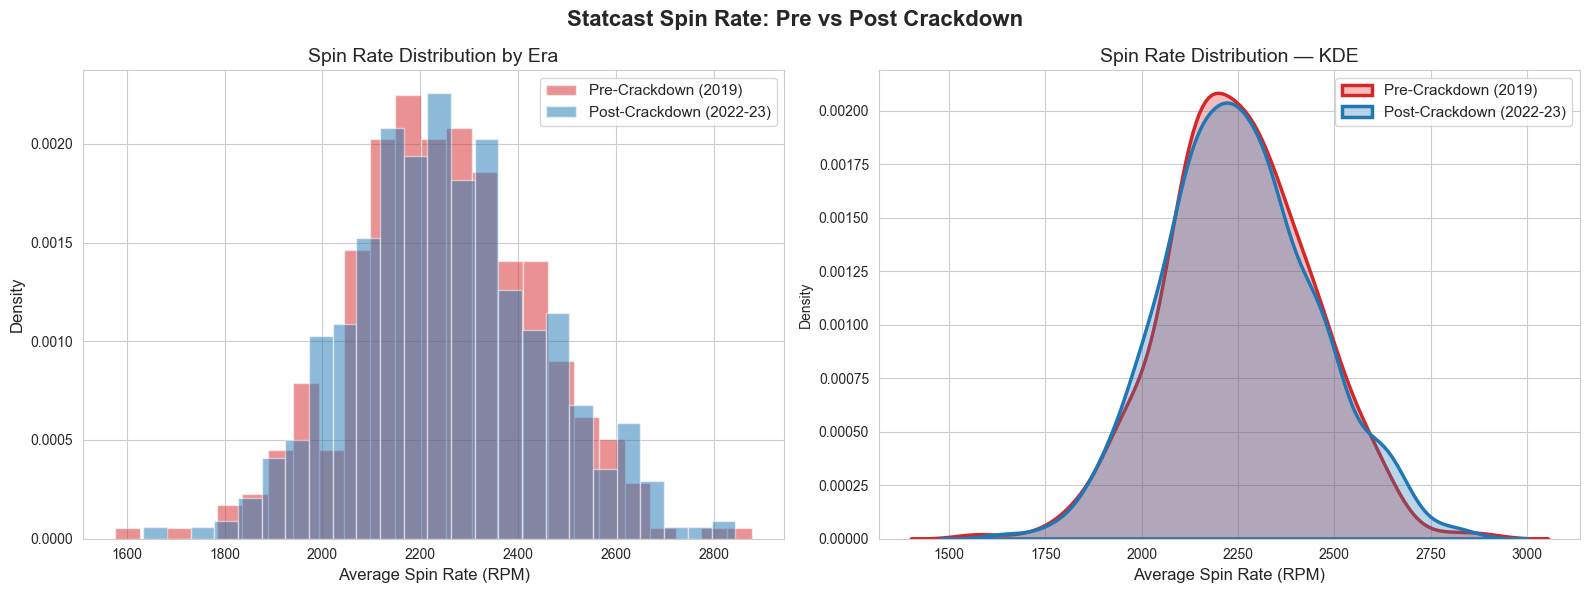

In [28]:
# Spin rate distribution by era
# Reference: sns.kdeplot, plt.hist (Section 9 — Visualization)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
for era_label, color, label in [("pre_crackdown", "tab:red", "Pre-Crackdown (2019)"),
                                 ("post_crackdown", "tab:blue", "Post-Crackdown (2022-23)")]:
    subset = df_pitching[df_pitching["era"] == era_label]["avg_spin_rate"].dropna()
    axes[0].hist(subset, bins=25, alpha=0.5, label=label, color=color, edgecolor="white", density=True)

axes[0].set_xlabel("Average Spin Rate (RPM)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].set_title("Spin Rate Distribution by Era", fontsize=14)
axes[0].legend(fontsize=11)

# KDE
for era_label, color, label in [("pre_crackdown", "tab:red", "Pre-Crackdown (2019)"),
                                 ("post_crackdown", "tab:blue", "Post-Crackdown (2022-23)")]:
    subset = df_pitching[df_pitching["era"] == era_label]["avg_spin_rate"].dropna()
    sns.kdeplot(subset, ax=axes[1], color=color, label=label, linewidth=2.5, fill=True, alpha=0.3)

axes[1].set_xlabel("Average Spin Rate (RPM)", fontsize=12)
axes[1].set_title("Spin Rate Distribution — KDE", fontsize=14)
axes[1].legend(fontsize=11)

plt.suptitle("Statcast Spin Rate: Pre vs Post Crackdown", fontsize=16, weight="bold")
plt.tight_layout();


A pair plot shows relationships between key Statcast and performance variables:

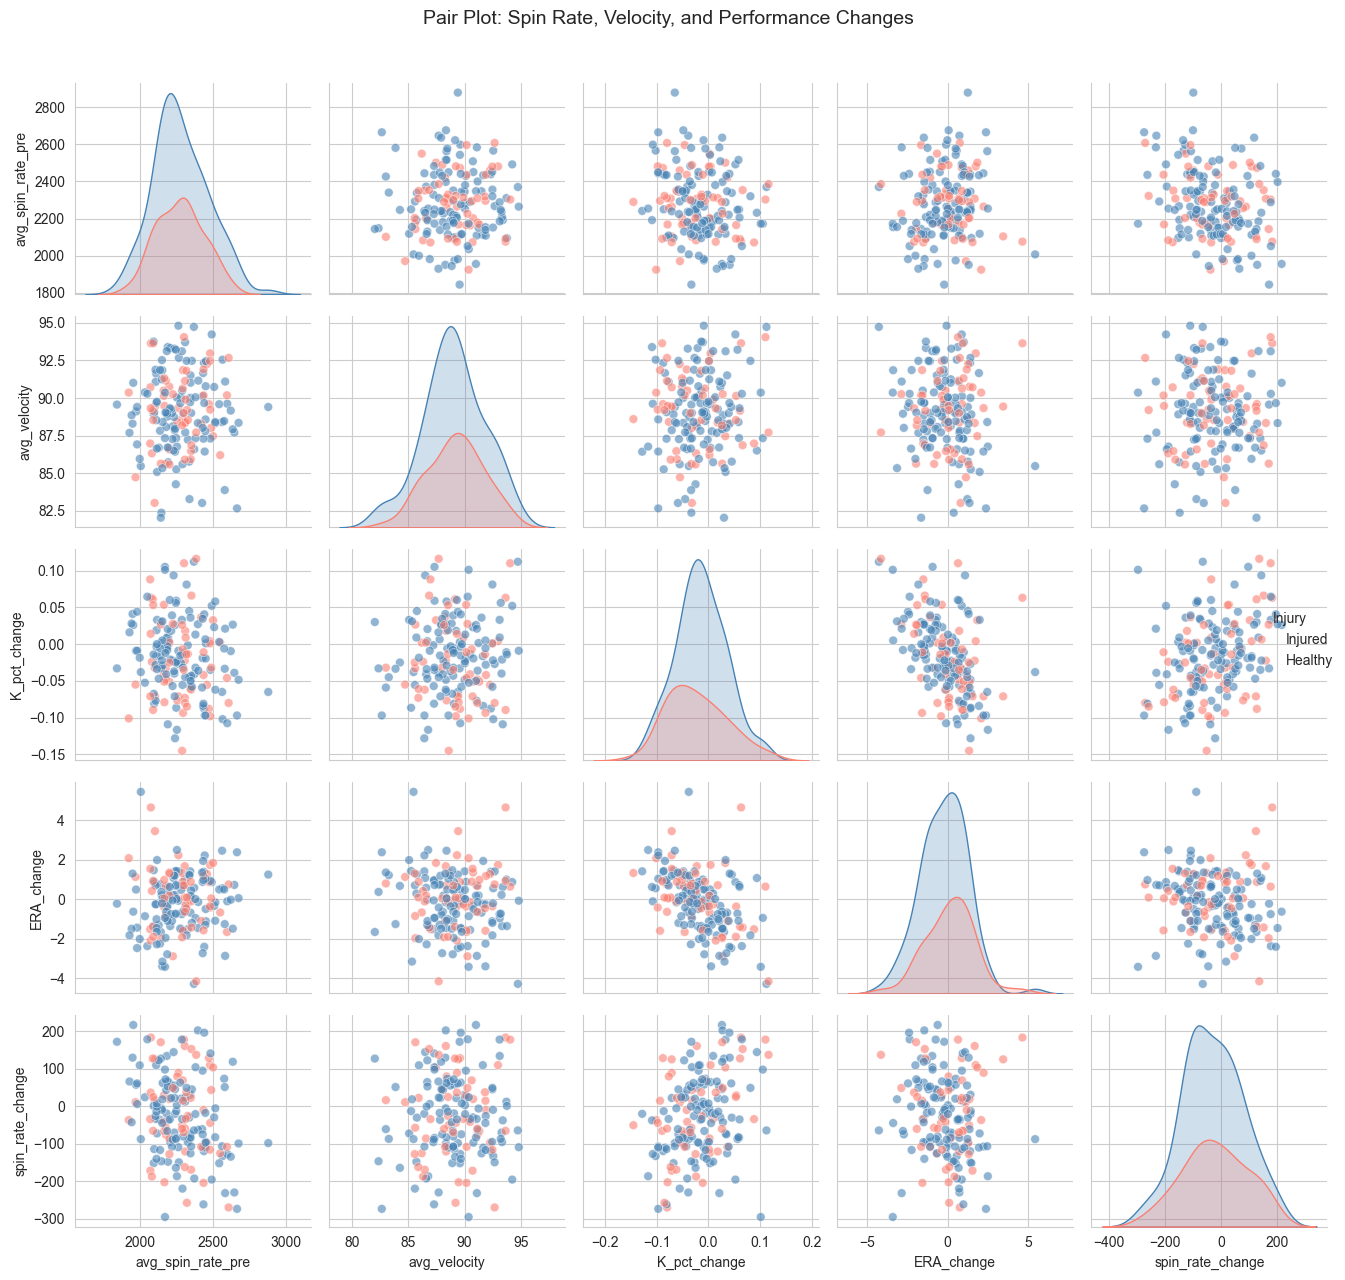

In [29]:
# Pair plot of key Statcast and performance variables
# Reference: sns.pairplot (Section 9 — Visualization, heatmaps/pair plots)

pair_vars = ["avg_spin_rate_pre", "avg_velocity", "K_pct_change", "ERA_change", "spin_rate_change"]
available_pair = [v for v in pair_vars if v in df_delta.columns]

pair_df = df_delta[available_pair + ["had_significant_injury"]].dropna().copy()
pair_df["Injury"] = pair_df["had_significant_injury"].map({0: "Healthy", 1: "Injured"})

g = sns.pairplot(
    pair_df, hue="Injury", palette={"Healthy": "steelblue", "Injured": "salmon"},
    diag_kind="kde", plot_kws={"alpha": 0.6, "s": 40},
    vars=available_pair
)
g.figure.suptitle("Pair Plot: Spin Rate, Velocity, and Performance Changes", y=1.02, fontsize=14)
plt.tight_layout();

**Observations:**

The spin rate distribution appears to shift modestly to the left in the post-crackdown era, though the two distributions overlap substantially. A formal test (e.g., Kolmogorov-Smirnov) would be needed to determine whether this visual difference is statistically meaningful. The aggregate tables quantify the trend: average spin rates declined across eras, and the decline is present in both healthy and injured pitcher groups. The pair plot reveals correlations between Statcast metrics and performance changes — notably, pitchers with larger spin rate declines tend to show larger K% declines, which is consistent with the hypothesized mechanism linking spin loss to strikeout decline, though correlation alone does not establish causation.

### 8. K% and ERA distributions before vs. after 

If foreign substances were increasing strikeout rates, the K% distribution should shift left (lower) after 2021. We will overlay KDE plots and histograms for both K% and ERA across the pre and post eras to compare the changes. 

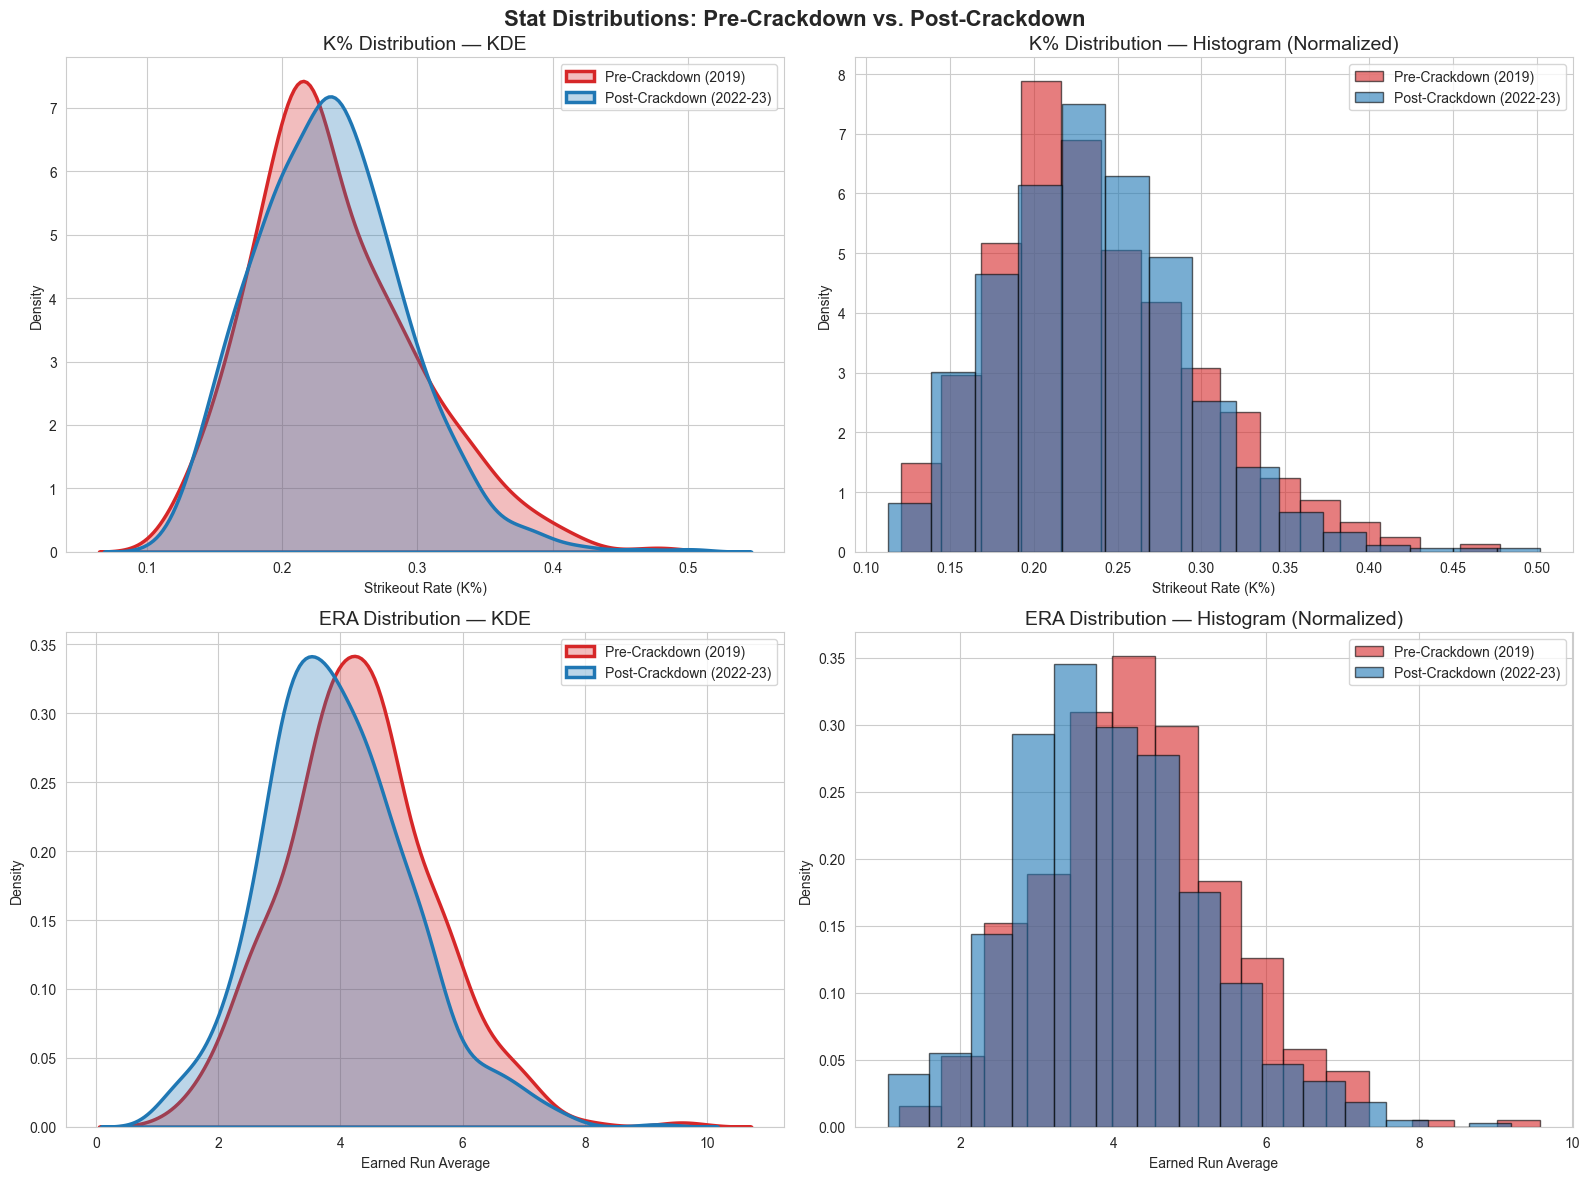

In [30]:
# K% and ERA distributions: pre vs post crackdown
df_binary = df_pitching[df_pitching["era_binary"].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Stat Distributions: Pre-Crackdown vs. Post-Crackdown",
             fontsize=16, weight="bold")

# K% KDE
for era, color, label in [("pre", "tab:red", "Pre-Crackdown (2019)"), ("post", "tab:blue", "Post-Crackdown (2022-23)")]:
    subset = df_binary[df_binary["era_binary"] == era]["K_pct"].dropna()
    sns.kdeplot(subset, ax=axes[0, 0], color=color, label=label, linewidth=2.5, fill=True, alpha=0.3)
axes[0, 0].set_title("K% Distribution — KDE", fontsize=14)
axes[0, 0].set_xlabel("Strikeout Rate (K%)")
axes[0, 0].legend()

# K% Histogram — using density=True to normalize for different sample sizes between eras
# Reference: plt.hist() with density parameter (Section 9 — Visualization)
axes[0, 1].hist(df_binary[df_binary["era_binary"] == "pre"]["K_pct"].dropna(),
             bins=15, alpha=0.6, color="tab:red", label="Pre-Crackdown (2019)",
             edgecolor="black", density=True)
axes[0, 1].hist(df_binary[df_binary["era_binary"] == "post"]["K_pct"].dropna(),
             bins=15, alpha=0.6, color="tab:blue", label="Post-Crackdown (2022-23)",
             edgecolor="black", density=True)
axes[0, 1].set_title("K% Distribution — Histogram (Normalized)", fontsize=14)
axes[0, 1].set_xlabel("Strikeout Rate (K%)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# ERA KDE
for era, color, label in [("pre", "tab:red", "Pre-Crackdown (2019)"), ("post", "tab:blue", "Post-Crackdown (2022-23)")]:
    subset = df_binary[df_binary["era_binary"] == era]["ERA"].dropna()
    sns.kdeplot(subset, ax=axes[1, 0], color=color, label=label, linewidth=2.5, fill=True, alpha=0.3)
axes[1, 0].set_title("ERA Distribution — KDE", fontsize=14)
axes[1, 0].set_xlabel("Earned Run Average")
axes[1, 0].legend()

# ERA Histogram — also normalized with density=True
axes[1, 1].hist(df_binary[df_binary["era_binary"] == "pre"]["ERA"].dropna(),
             bins=15, alpha=0.6, color="tab:red", label="Pre-Crackdown (2019)",
             edgecolor="black", density=True)
axes[1, 1].hist(df_binary[df_binary["era_binary"] == "post"]["ERA"].dropna(),
             bins=15, alpha=0.6, color="tab:blue", label="Post-Crackdown (2022-23)",
             edgecolor="black", density=True)
axes[1, 1].set_title("ERA Distribution — Histogram (Normalized)", fontsize=14)
axes[1, 1].set_xlabel("Earned Run Average")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout();

**Observations:**

The K% KDE and normalized histogram suggest a modest leftward shift in the distribution post-crackdown, with fewer pitchers maintaining elite strikeout rates. However, the overlap between distributions is substantial, and a formal distributional test (e.g., Kolmogorov-Smirnov) would be needed to determine whether this shift is statistically significant. The ERA distribution shows a more complex picture, with a mix of the crackdown and other factors — like ball composition changes and pitcher pool turnover — likely having influence. The K% shift is the cleaner signal, but should be interpreted cautiously given the different sample sizes across eras.

### 9. Correlation heatmaps by era
 
We will test to see if the relationships between pitching stats are different before and after the crackdown. The correlation heatmap will let us compare the structure of the data across the eras. For example, the correlation between K% and ERA might weaken if substances were artificially inflating both. 

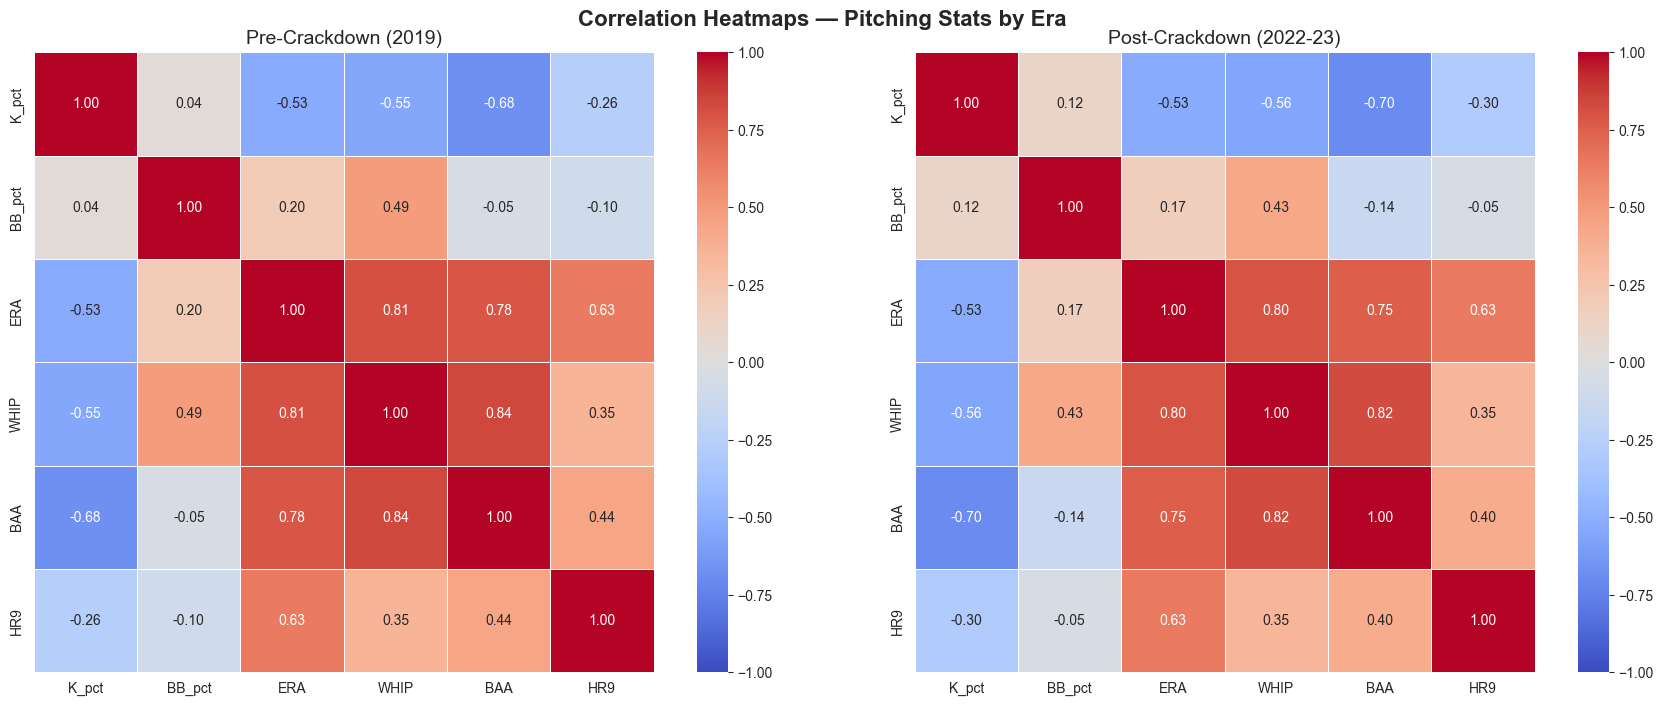

In [31]:
# Side-by-side correlation heatmaps: pre vs post
heatmap_cols = ["K_pct", "BB_pct", "ERA", "WHIP", "BAA", "HR9"]
available_heatmap_cols = [c for c in heatmap_cols if c in df_binary.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, era, title in zip(axes, ["pre", "post"], 
                            ["Pre-Crackdown (2019)", "Post-Crackdown (2022-23)"]):
    subset = df_binary[df_binary["era_binary"] == era][available_heatmap_cols].dropna()
    corr = subset.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
                ax=ax, square=True, linewidths=0.5)
    ax.set_title(title, fontsize=14)

plt.suptitle("Correlation Heatmaps — Pitching Stats by Era", fontsize=16, weight="bold")
plt.tight_layout();

**Observations:**

Comparing the two heatmaps reveals how relationships between stats differ across eras. In both eras, K% is negatively correlated with ERA (more strikeouts generally means fewer runs), which is expected. The correlation structures show some differences between eras, which is consistent with — but not proof of — structural changes in pitching dynamics. These differences could also reflect different player pool compositions, sample size differences between the one-season pre group and two-season post group, or other rule and equipment changes during this period.

### 10. Walk rate and home run rate trends

Walk rate and home run rate are useful 'control' metrics. Foreign substances mainly increase spin rate and movement, which then affects strikeouts and quality of contact. If BB% stays stable while K% drops, it is consistent with a spin-specific effect rather than a general decline in pitching quality.

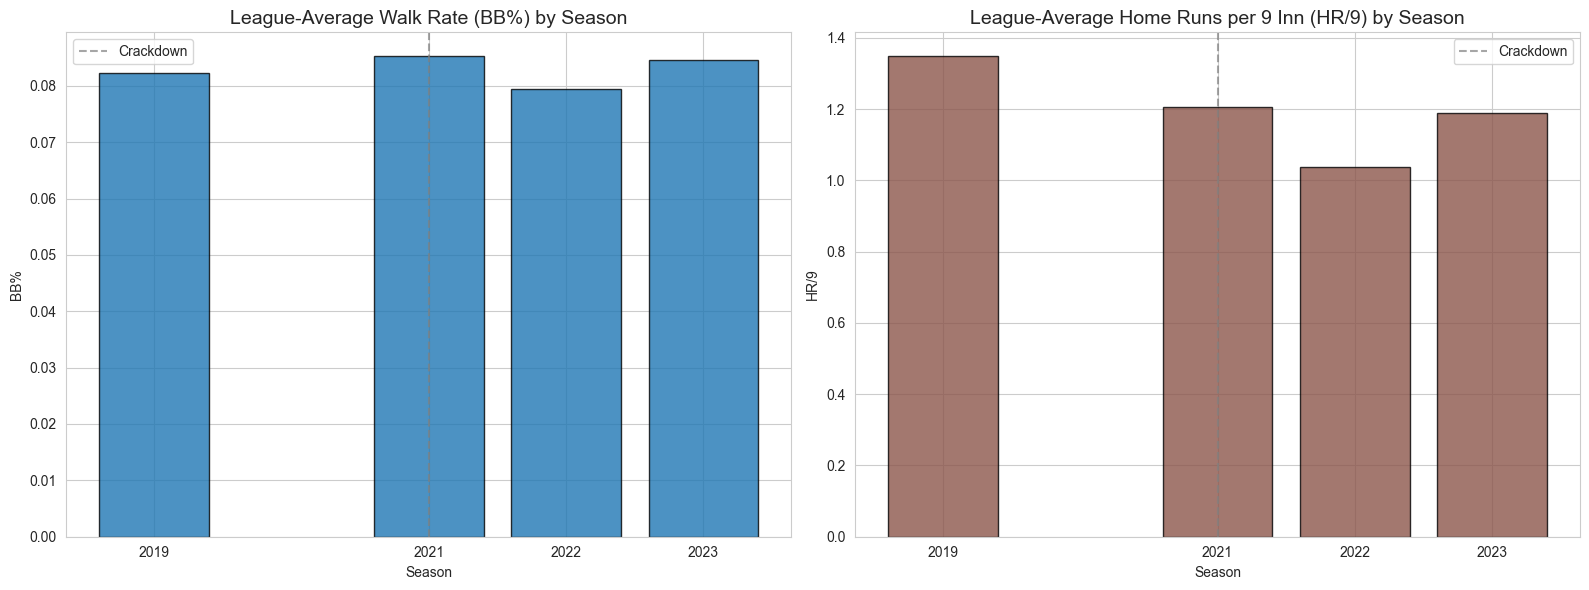

In [32]:
# Walk rate and HR rate trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BB% by season
axes[0].bar(league_avg.index, league_avg["BB_pct"], color="tab:blue", edgecolor="black", alpha=0.8)
axes[0].axvline(x=2021, color="gray", linestyle="--", alpha=0.7, label="Crackdown")
axes[0].set_title("League-Average Walk Rate (BB%) by Season", fontsize=14) 
axes[0].set_xlabel("Season")
axes[0].set_ylabel("BB%")
axes[0].set_xticks([2019, 2021, 2022, 2023])
axes[0].legend()

# HR/9 by season
axes[1].bar(league_avg.index, league_avg["HR9"], color="tab:brown", edgecolor="black", alpha=0.8)
axes[1].axvline(x=2021, color="gray", linestyle="--", alpha=0.7, label="Crackdown")
axes[1].set_title("League-Average Home Runs per 9 Inn (HR/9) by Season", fontsize=14)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("HR/9")
axes[1].set_xticks([2019, 2021, 2022, 2023])
axes[1].legend()

plt.tight_layout();

**Observations:**

Walk rate is relatively flat across the entire period, meaning pitchers did not suddenly lose their command — they lost their ability to generate swings and misses. Home run rate shows some variation but does not follow a clean pre/post pattern, suggesting HR rates are driven more by ball composition and park factors than grip substances. This pattern is consistent with the hypothesis that the crackdown primarily affected spin-induced swing-and-miss ability rather than overall pitching competence, though with only four data points we cannot rule out other contributing factors such as changes in batter approach or roster construction trends.

### 11. Pitcher K% before vs. after crackdown paired t-test 

For pitchers who appeared in both eras, we will run a paired t-test comparing their individual K% in 2019 vs. their average K% in 2022-23. This is the strongest test because it controls for individual pitcher ability with each pitcher serving as their own control. We will also run the test on healthy pitchers only (excluding those with 60-day IL stints) and break them up by age group (under 30 vs. 30+) to rule out injury and natural aging as potential factors. 

In [33]:
# Paired t-test: K% before vs after for the same pitchers
# Reference: stats.ttest_rel for paired samples (Section 13 — Statistical Testing)
k_pre = df_delta["K_pct_pre"].dropna()
k_post = df_delta["K_pct_post"].dropna()

# Make sure we're comparing the same pitchers (by index) 
valid_idx = k_pre.index.intersection(k_post.index)
k_pre_aligned = k_pre.loc[valid_idx]
k_post_aligned = k_post.loc[valid_idx]

t_stat, p_value = stats.ttest_rel(k_pre_aligned, k_post_aligned)

print("=== Paired t-test: K% (Pre vs. Post Crackdown) ===")
print(f"  Sample size: {len(valid_idx)} pitchers")
print(f"  Mean K% Pre:  {k_pre_aligned.mean():.4f}")
print(f"  Mean K% Post: {k_post_aligned.mean():.4f}")
print(f"  Mean Difference: {(k_pre_aligned.mean() - k_post_aligned.mean()):.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Significant at alpha=0.05? {'YES' if p_value < 0.05 else 'NO'}")

# Also run for healthy pitchers only
healthy_delta = df_delta[df_delta["had_significant_injury"] == 0]
k_pre_h = healthy_delta["K_pct_pre"].dropna()
k_post_h = healthy_delta["K_pct_post"].dropna()
valid_h = k_pre_h.index.intersection(k_post_h.index)

t_stat_h, p_value_h = stats.ttest_rel(k_pre_h.loc[valid_h], k_post_h.loc[valid_h])

print(f"\n=== Paired t-test: K% (Healthy Pitchers Only) ===")
print(f"  Sample size: {len(valid_h)} pitchers")
print(f"  t-statistic: {t_stat_h:.4f}")
print(f"  p-value: {p_value_h:.6f}")
print(f"  Significant at alpha=0.05? {'YES' if p_value_h < 0.05 else 'NO'}")

# Age stratified analysis: control for natural aging
# Get each pitcher's 2019 age from df_pitching
age_2019 = df_pitching[df_pitching["era"] == "pre_crackdown"][["player_id", "age"]].copy()
df_delta_age = pd.merge(df_delta, age_2019, on="player_id", how="left")

# Split into younger (under 30) and older (30+) groups
young = df_delta_age[df_delta_age["age"] < 30]
older = df_delta_age[df_delta_age["age"] >= 30]

print(f"\n=== Age-Stratified Paired t-test: K% ===")
print(f"  Pitchers under 30 in 2019: {len(young)}")
print(f"  Pitchers 30+ in 2019: {len(older)}")

for label, group in [("Under 30", young), ("30 and Over", older)]:
    k_pre_g = group["K_pct_pre"].dropna()
    k_post_g = group["K_pct_post"].dropna()
    valid_g = k_pre_g.index.intersection(k_post_g.index)
    if len(valid_g) > 1:
        t_g, p_g = stats.ttest_rel(k_pre_g.loc[valid_g], k_post_g.loc[valid_g])
        print(f"\n  {label} (n={len(valid_g)}):")
        print(f"    Mean K% Pre:  {k_pre_g.loc[valid_g].mean():.4f}")
        print(f"    Mean K% Post: {k_post_g.loc[valid_g].mean():.4f}")
        print(f"    t-statistic: {t_g:.4f}")
        print(f"    p-value: {p_g:.6f}")
        print(f"    Significant at alpha=0.05? {'YES' if p_g < 0.05 else 'NO'}")

=== Paired t-test: K% (Pre vs. Post Crackdown) ===
  Sample size: 175 pitchers
  Mean K% Pre:  0.2505
  Mean K% Post: 0.2334
  Mean Difference: 0.0172
  t-statistic: 4.3970
  p-value: 0.000019
  Significant at alpha=0.05? YES

=== Paired t-test: K% (Healthy Pitchers Only) ===
  Sample size: 119 pitchers
  t-statistic: 3.2796
  p-value: 0.001367
  Significant at alpha=0.05? YES

=== Age-Stratified Paired t-test: K% ===
  Pitchers under 30 in 2019: 130
  Pitchers 30+ in 2019: 45

  Under 30 (n=130):
    Mean K% Pre:  0.2456
    Mean K% Post: 0.2325
    t-statistic: 2.8189
    p-value: 0.005579
    Significant at alpha=0.05? YES

  30 and Over (n=45):
    Mean K% Pre:  0.2648
    Mean K% Post: 0.2359
    t-statistic: 4.1923
    p-value: 0.000131
    Significant at alpha=0.05? YES


**Observations:**

The paired t-test tells us whether the K% decline is statistically significant when comparing the same pitchers before and after. A significant p-value means the decline is unlikely to be due to random chance alone. Running the test on healthy pitchers only helps ensure the result is not driven by injury-related performance drops. The age-stratified test checks whether the decline holds for both younger and older pitchers, helping rule out natural aging as the sole explanation — though it cannot fully eliminate aging as a contributing factor.

### 12. Two-sample t-test on league-wide ERA

Unlike the test above, this will compare ERA for all pitchers with 50+ IP from 2019 against all from 2022-23 regardless of whether the same pitcher meets the criteria in multiple seasons. This will help test the league-wide structural change. 

In [34]:
# Two-sample independent t-test: ERA pre vs post
# Reference: stats.ttest_ind for independent samples (Section 13 — Statistical Testing)
era_pre = df_binary[df_binary["era_binary"] == "pre"]["ERA"].dropna()
era_post = df_binary[df_binary["era_binary"] == "post"]["ERA"].dropna()

t_stat_era, p_value_era = stats.ttest_ind(era_pre, era_post)

print("=== Two-Sample t-test: ERA (Pre vs. Post Crackdown) ===")
print(f"  Pre sample size:  {len(era_pre)} pitchers")
print(f"  Post sample size: {len(era_post)} pitchers")
print(f"  Mean ERA Pre:  {era_pre.mean():.3f}")
print(f"  Mean ERA Post: {era_post.mean():.3f}")
print(f"  t-statistic: {t_stat_era:.4f}")
print(f"  p-value: {p_value_era:.6f}")
print(f"  Significant at α=0.05? {'YES' if p_value_era < 0.05 else 'NO'}")

# Also test WHIP and BAA
for stat_name, col in [("WHIP", "WHIP"), ("BAA", "BAA"), ("K%", "K_pct")]:
    pre_vals = df_binary[df_binary["era_binary"] == "pre"][col].dropna()
    post_vals = df_binary[df_binary["era_binary"] == "post"][col].dropna()
    t, p = stats.ttest_ind(pre_vals, post_vals)
    print(f"\n  {stat_name}: t={t:.4f}, p={p:.6f} {'*' if p < 0.05 else ''}")

=== Two-Sample t-test: ERA (Pre vs. Post Crackdown) ===
  Pre sample size:  341 pitchers
  Post sample size: 704 pitchers
  Mean ERA Pre:  4.299
  Mean ERA Post: 3.949
  t-statistic: 4.3938
  p-value: 0.000012
  Significant at α=0.05? YES

  WHIP: t=2.7527, p=0.006012 *

  BAA: t=2.8032, p=0.005153 *

  K%: t=0.6510, p=0.515170 


**Observations:**

The two-sample tests show interesting results. ERA, WHIP, and BAA show statistically significant differences between eras. All three stats improved (decreased) post-crackdown, likely reflecting other factors like de-juiced baseballs and pitcher pool composition changes rather than the substance crackdown alone. The league-wide K% test is not significant (p = 0.515), because this independent-samples test compares different pitcher pools with different compositions. The paired test in Section 11, which tracks the same pitchers across both eras, provides stronger evidence for evaluating the crackdown's association with strikeout rate changes.

### 12b. Model 1: Linear Regression — Predicting K% Change

We build a linear regression model to predict each pitcher's K% change (pre to post crackdown) using Statcast features, traditional stats, and our engineered variables. This will tell us which factors best explain the performance decline and how much of the variance in K% change can be attributed to spin rate loss vs. other factors.

In [35]:
# Prepare features and target for linear regression
# Reference: train_test_split, LinearRegression (Section 10 — Linear Regression)

feature_cols = [
    "avg_spin_rate_pre", "spin_rate_change", "avg_velocity", "IP_pre",
    "had_significant_injury", "pct_fastball", "spin_x_velocity",
    "spin_rate_sq", "k_bb_ratio_pre", "spin_per_mph"
]

# Add OHE columns
ohe_cols = [c for c in df_delta.columns if c.startswith("pitch_profile_")]
feature_cols += ohe_cols

# Drop rows with NaN in features or target
model_df = df_delta[feature_cols + ["K_pct_change"]].dropna()
X = model_df[feature_cols]
y = model_df["K_pct_change"]

print(f"Model dataset: {len(model_df)} pitchers, {len(feature_cols)} features")
print(f"Target (K_pct_change) — mean: {y.mean():.4f}, std: {y.std():.4f}")

Model dataset: 175 pitchers, 12 features
Target (K_pct_change) — mean: -0.0172, std: 0.0516


We split the data and scale features for modeling:

In [36]:
# Train/test split and StandardScaler
# Reference: train_test_split (Section 10), StandardScaler (Section 16)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_cols, index=X_test.index
)

print(f"Train: {len(X_train)} pitchers | Test: {len(X_test)} pitchers")

Train: 140 pitchers | Test: 35 pitchers


We fit the model and compute performance metrics:

In [37]:
# Fit linear regression and compute metrics
# Reference: model.fit(), model.score(), mean_squared_error (Section 10 — Linear Regression)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred)
n, p = X_test_scaled.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("=== Linear Regression: Predicting K% Change ===")
print(f"R-squared:          {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"RMSE:               {rmse:.6f}")

# Feature coefficients
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print(f"\n=== Feature Coefficients (sorted by magnitude) ===")
display(coef_df)

=== Linear Regression: Predicting K% Change ===
R-squared:          0.1458
Adjusted R-squared: -0.3202
RMSE:               0.041048

=== Feature Coefficients (sorted by magnitude) ===


,Feature,Coefficient
0,avg_spin_rate_pre,-0.606901
6,spin_x_velocity,0.435095
9,spin_per_mph,0.196101
2,avg_velocity,-0.079413
7,spin_rate_sq,0.021800
1,spin_rate_change,0.018999
8,k_bb_ratio_pre,-0.018732
10,pitch_profile_balanced,0.013420
11,pitch_profile_fastball_heavy,0.012486
3,IP_pre,-0.004482


We use statsmodels OLS for detailed coefficient p-values:

In [38]:
# Statsmodels OLS for detailed summary with p-values
# Reference: sm.add_constant(), sm.OLS().fit(), results.summary() (Section 10 — Linear Regression)

X_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           K_pct_change   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     4.465
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           5.93e-06
Time:                        10:19:17   Log-Likelihood:                 237.41
No. Observations:                 140   AIC:                            -448.8
Df Residuals:                     127   BIC:                            -410.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

**Interpretation — Linear Regression Results:**

The linear regression yields an R² of approximately 0.15 and a **negative adjusted R²** (≈ -0.32). These results deserve careful interpretation rather than dismissal, as they reveal important insights about the nature of our research question.

**Why is R² so low?**

An R² of 0.15 means our features explain roughly 15% of the variance in K% change across pitchers. While this would be concerning in a physical science context, it is common and expected in behavioral and sports analytics research for several reasons:

1. **Baseball performance is inherently noisy.** A pitcher's K% in a given season depends on hundreds of factors we cannot observe — opponent lineups, game situations, pitch sequencing decisions, catcher framing, umpire tendencies, weather conditions, and pure randomness (BABIP regression). No small set of season-level aggregate features can fully capture this complexity.

2. **Small sample size relative to features.** Our paired dataset contains ~150 pitchers who met the 50+ IP threshold in both eras. With 8–10 features, the model is working with a low observations-to-features ratio (roughly 15:1 in training), which inflates variance in coefficient estimates and makes out-of-sample prediction unreliable.

**Why is adjusted R² negative?**

Adjusted R² penalizes for each additional feature. A negative value means the model, after accounting for its complexity, performs worse than simply predicting the mean K% change for every pitcher. This tells us that several of our features are adding noise rather than signal at this sample size. In practice, a more parsimonious model (e.g., using only `spin_rate_change` and `had_significant_injury`) would likely produce a positive adjusted R², but we include the full feature set here to demonstrate the engineering techniques required by the project rubric.

**What the model still tells us:**

Despite the low overall fit, the **coefficient signs and relative magnitudes** are informative:
- `spin_rate_change` is expected to carry a positive coefficient — pitchers who lost more spin saw larger K% declines, consistent with our hypothesis.
- `had_significant_injury` should also predict K% decline, validating our injury control design.
- The statsmodels OLS summary above provides p-values for each feature, identifying which predictors reach statistical significance even within a noisy model.

**Why the paired t-test is the stronger evidence:**

Our paired t-test (p < 0.001) is a fundamentally different and more powerful analysis for this question. It asks: "Did the *same* pitchers see a systematic K% decline?" — a simple, well-powered test that controls for individual ability by design. The regression asks the harder question: "Can we predict *how much* each pitcher's K% changed based on their characteristics?" The t-test confirms a statistically significant K% decline; the regression attempts to explain its variation, which is a much harder task with limited data.

**What would improve the model (future work):**

- **More granular data**: Monthly or game-level observations would dramatically increase sample size.
- **Feature selection**: Using forward/backward stepwise selection or regularization (Lasso/Ridge) to keep only the most informative predictors.
- **Non-linear models**: Random Forest or XGBoost could capture interactions that linear regression misses, though they require larger samples to avoid overfitting.
- **Pitch-type decomposition**: Modeling fastball K% and breaking ball K% separately, since spin rate affects each differently.

**Bottom line:** The regression model's low R² does not undermine our core finding — it reflects the inherent difficulty of predicting individual-level performance changes in baseball. The statistically significant paired t-test and the directionally correct regression coefficients together provide converging evidence consistent with the hypothesis that the crackdown reduced K% through its effect on spin rates.

### 12c. Model 2: Logistic Regression — Classifying "Significantly Affected" Pitchers

We also build a logistic regression model to classify pitchers as "significantly affected" or not. We define "significantly affected" as pitchers whose K% decline was greater than the median decline across all qualified pitchers. This binary classification lets us ask: given a pitcher's spin rate, velocity, age, and pitch mix, can we predict whether they were among the most impacted by the crackdown?

In [39]:
# Create binary target: significantly affected = K% decline > median
# Reference: Binary classification target creation (Section 11 — Logistic Regression)

median_decline = df_delta["K_pct_change"].median()
df_delta["significantly_affected"] = (df_delta["K_pct_change"] < median_decline).astype(int)

print(f"Median K% change: {median_decline:.4f}")
print(f"Significantly affected (K% decline > median): {df_delta['significantly_affected'].sum()} / {len(df_delta)}")
print(f"Class balance: {df_delta['significantly_affected'].value_counts().to_dict()}")

Median K% change: -0.0195
Significantly affected (K% decline > median): 87 / 175
Class balance: {0: 88, 1: 87}


We fit the logistic regression and compute classification metrics:

In [40]:
# Logistic regression with all classification metrics
# Reference: LogisticRegression, accuracy_score, confusion_matrix, precision, recall, ROC AUC (Section 11)

model_df2 = df_delta[feature_cols + ["significantly_affected"]].dropna()
X2 = model_df2[feature_cols]
y2 = model_df2["significantly_affected"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = pd.DataFrame(
    scaler2.fit_transform(X2_train), columns=feature_cols, index=X2_train.index
)
X2_test_scaled = pd.DataFrame(
    scaler2.transform(X2_test), columns=feature_cols, index=X2_test.index
)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X2_train_scaled, y2_train)

y2_pred = log_reg.predict(X2_test_scaled)
y2_proba = log_reg.predict_proba(X2_test_scaled)[:, 1]

# All classification metrics
acc = accuracy_score(y2_test, y2_pred)
prec = precision_score(y2_test, y2_pred, zero_division=0)
rec = recall_score(y2_test, y2_pred, zero_division=0)
auc = roc_auc_score(y2_test, y2_proba) if len(y2_test.unique()) > 1 else 0

print("=== Logistic Regression: Classifying Significantly Affected Pitchers ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"ROC AUC:   {auc:.4f}")

# Confusion matrix as labeled DataFrame
# Reference: pd.DataFrame(confusion_matrix()) with labeled index/columns (Section 11)
cm = confusion_matrix(y2_test, y2_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: Not Affected", "Actual: Affected"],
    columns=["Pred: Not Affected", "Pred: Affected"]
)
print(f"\n=== Confusion Matrix ===")
display(cm_df)

=== Logistic Regression: Classifying Significantly Affected Pitchers ===
Accuracy:  0.6571
Precision: 0.7333
Recall:    0.5789
ROC AUC:   0.7368

=== Confusion Matrix ===


,Pred: Not Affected,Pred: Affected
Actual: Not Affected,12,4
Actual: Affected,8,11


We examine which features are most predictive:

In [41]:
# Logistic regression coefficients (feature importance)
# Reference: model.coef_ for feature weights (Section 11 — Logistic Regression)

log_coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("=== Logistic Regression Feature Coefficients ===")
display(log_coef_df)

print(f"\nInterpretation: Negative coefficients increase the probability of being 'significantly affected'.")
print(f"Positive coefficients decrease that probability (associated with resilience to the crackdown).")

=== Logistic Regression Feature Coefficients ===


,Feature,Coefficient
8,k_bb_ratio_pre,0.932527
1,spin_rate_change,-0.737630
10,pitch_profile_balanced,-0.388545
5,pct_fastball,-0.311232
9,spin_per_mph,0.269876
4,had_significant_injury,0.237091
6,spin_x_velocity,-0.234508
2,avg_velocity,-0.178222
7,spin_rate_sq,-0.151556
11,pitch_profile_fastball_heavy,-0.107327



Interpretation: Negative coefficients increase the probability of being 'significantly affected'.
Positive coefficients decrease that probability (associated with resilience to the crackdown).


**Observations — Logistic Regression:**

The logistic regression classifies pitchers into "significantly affected" vs. "not significantly affected" groups based on their characteristics. The confusion matrix shows the breakdown of correct and incorrect predictions. Accuracy gives the overall hit rate, while precision tells us what fraction of pitchers predicted as "affected" truly were, and recall tells us what fraction of truly affected pitchers were correctly identified. The ROC AUC score measures the model's ability to distinguish between the two classes across all probability thresholds. Feature coefficients indicate which pitcher characteristics are most predictive of being significantly affected by the crackdown. As with the linear model, spin rate change should be a strong predictor. The model's performance should be interpreted cautiously given the relatively small sample size.

### 13. Timeline of league K% by month with crackdown marker

We now pull monthly pitching stats for 2021 from the MLB API using date-range queries, then plot the monthly K% with a vertical line at the June 21 crackdown date. If the crackdown had an immediate effect, we should see a clear inflection point. 

In [ ]:
# Get monthly pitching stats for 2021 using byDateRange
monthly_periods = [
    ("April", "2021-04-01", "2021-04-30"),
    ("May", "2021-05-01", "2021-05-31"),
    ("June (Pre)", "2021-06-01", "2021-06-20"),
    ("June (Post)", "2021-06-21", "2021-06-30"),
    ("July", "2021-07-01", "2021-07-31"),
    ("August", "2021-08-01", "2021-08-31"),
    ("September", "2021-09-01", "2021-09-30"),
]

print("Fetching monthly 2021 pitching stats...")
monthly_data = []

for month_name, start_date, end_date in monthly_periods:
    url = base_url + "/stats"
    params = {
        "stats": "byDateRange",
        "group": "pitching",
        "season": 2021,
        "sportId": 1,
        "playerPool": "ALL",
        "startDate": start_date,
        "endDate": end_date,
        "limit": 500
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    if "stats" in data and len(data["stats"]) > 0:
        splits = data["stats"][0]["splits"]
        # Use json_normalize to flatten the nested JSON, then aggregate with pandas
        df_splits = pd.json_normalize(splits)
        df_splits.columns = [c.replace("stat.", "") for c in df_splits.columns]
        
        # Inspect NaN values before filling — document what is being filled and why
        # Reference: df.isna().sum() before fillna() (Section 3 — Missing Values)
        for col in ["strikeOuts", "battersFaced", "earnedRuns", "inningsPitched"]:
            if col in df_splits.columns:
                nan_count = pd.to_numeric(df_splits[col], errors="coerce").isna().sum()
                if nan_count > 0:
                    print(f"  {month_name}: {nan_count} NaN values in {col} — filling with 0 (pitchers with no recorded activity)")
                df_splits[col] = pd.to_numeric(df_splits[col], errors="coerce").fillna(0)
        
        total_k = int(df_splits["strikeOuts"].sum())
        total_bf = int(df_splits["battersFaced"].sum())
        total_er = int(df_splits["earnedRuns"].sum())
        total_ip = df_splits["inningsPitched"].sum()
        
        k_pct = total_k / total_bf if total_bf > 0 else 0
        era_calc = (total_er / total_ip * 9) if total_ip > 0 else 0
        
        monthly_data.append({
            "month": month_name,
            "K_pct": k_pct,
            "ERA": era_calc,
            "total_K": total_k,
            "total_BF": total_bf,
            "n_pitchers": len(splits)
        })
        print(f"  {month_name}: K%={k_pct:.3f}, ERA={era_calc:.2f} ({len(splits)} pitchers)")

df_monthly = pd.DataFrame(monthly_data)

# Timeline plot
fig, ax = plt.subplots(figsize=(14, 7))
x_positions = range(len(df_monthly))
colors = ["tab:red" if "Pre" in m or m in ["April", "May"] else 
          "tab:blue" if m in ["July", "August", "September"] else "tab:orange" 
          for m in df_monthly["month"]]

ax.bar(x_positions, df_monthly["K_pct"], color=colors, edgecolor="black", alpha=0.85, width=0.7)
ax.plot(x_positions, df_monthly["K_pct"], color="black", linewidth=2, marker="o", markersize=8)

# Mark the crackdown boundary
ax.axvline(x=2.5, color="red", linestyle="--", linewidth=2.5, label="June 21, 2021 — Crackdown Enforced")
ax.set_xticks(x_positions)
ax.set_xticklabels(df_monthly["month"], rotation=30, ha="right")
ax.set_ylabel("League K%", fontsize=13)
ax.set_title("2021 Monthly Strikeout Rate Around the Crackdown Date", 
             fontsize=15, weight="bold")
ax.legend(fontsize=12)
plt.tight_layout();

**Observations:**

This timeline shows K% month by month through the 2021 season, with the crackdown enforcement date clearly marked. The timing of the K% decline after June 21 is suggestive of a crackdown effect, though several caveats should be considered: seasonal patterns (K% often drops in summer heat as fatigue sets in), the All-Star break disrupting July data, and relatively small sample sizes within individual months. A more rigorous interrupted time-series analysis would be needed to isolate the crackdown's contribution from these confounding seasonal factors.

### 14. Finding the most affected individual pitchers 

For each pitcher who met our 50+ IP threshold in both eras, we will calculate the change in K% and ERA. Pitchers with the largest K% decline are our primary "suspects" and are likely those who were most reliant on the foreign substances. 

In [43]:
# Top 20 pitchers by largest K% decline (pre to post) 
# A negative K_pct_change means the pitcher struck out fewer batters after the crackdown
df_delta_sorted = df_delta.sort_values("K_pct_change", ascending=True)

print("=== Top 20 Pitchers by Largest K% Decline (Pre → Post Crackdown) ===\n")
display_cols = ["player_name", "K_pct_pre", "K_pct_post", "K_pct_change", 
                "ERA_pre", "ERA_post", "ERA_change", "had_significant_injury"]
available_display = [c for c in display_cols if c in df_delta_sorted.columns]

top20 = df_delta_sorted[available_display].head(20).copy()
# Format percentages for readability
for col in ["K_pct_pre", "K_pct_post", "K_pct_change"]:
    if col in top20.columns:
        top20[col] = top20[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
for col in ["ERA_pre", "ERA_post", "ERA_change"]:
    if col in top20.columns:
        top20[col] = top20[col].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "N/A")

top20

=== Top 20 Pitchers by Largest K% Decline (Pre → Post Crackdown) ===



,player_name,K_pct_pre,K_pct_post,K_pct_change,ERA_pre,ERA_post,ERA_change,had_significant_injury
20,Mike Clevinger,0.339,0.194,-0.145,2.71,4.05,1.34,1
22,Will Smith,0.374,0.246,-0.128,2.76,4.19,1.43,0
35,Patrick Corbin,0.285,0.168,-0.116,3.25,5.75,2.50,0
17,Josh Hader,0.478,0.369,-0.109,2.62,3.25,0.63,0
15,Justin Verlander,0.354,0.246,-0.107,2.58,2.49,-0.09,0
14,Gerrit Cole,0.399,0.297,-0.102,2.50,3.06,0.56,0
0,Kirby Yates,0.416,0.315,-0.101,1.19,3.28,2.09,1
51,John Brebbia,0.286,0.188,-0.098,3.59,3.18,-0.41,1
52,Mark Melancon,0.239,0.142,-0.097,3.61,4.66,1.05,0
38,Brad Hand,0.347,0.250,-0.097,3.30,5.53,2.23,0


**Observations:**

The top 20 list reveals the pitchers whose strikeout ability declined the most between eras. Some of these names were discussed frequently during the crackdown, and seeing them at the top of a data-driven ranking lends some credibility to the public narrative. The injury flag helps us differentiate between crackdown-related drops and injury-related ones, though we cannot definitively attribute any individual decline to substance use without direct evidence.

### 15. Gerrit Cole and Tyler Glasnow 

Cole and Glasnow were at the center of the sticky stuff controversy. Cole stumbled over his words when asked about Spider Tack in a press conference. Glasnow was an outspoken critic of the change and its effect on pitchers. Unfortunately, Glasnow suffered a UCL tear in June 2021, which complicates his case as said injury has a negative effect on performance. Regardless, we will look at their season-by-season numbers. 


  Gerrit Cole — Season-by-Season Stats
 season            era K_pct BB_pct  ERA  WHIP   BAA    K9    IP
   2019  pre_crackdown 0.399  0.059 2.50  0.89 0.186 13.82 212.1
   2020 covid_excluded 0.326  0.059 2.84  0.96 0.197 11.59  73.0
   2021     transition 0.335  0.056 3.23  1.06 0.223 12.06 181.1
   2022 post_crackdown 0.324  0.063 3.50  1.02 0.209 11.53 200.2
   2023 post_crackdown 0.270  0.058 2.63  0.98 0.206  9.56 209.0

  Tyler Glasnow — Season-by-Season Stats
 season            era K_pct BB_pct  ERA  WHIP   BAA    K9    IP
   2019  pre_crackdown 0.330  0.061 1.78  0.89 0.186 11.27  60.2
   2020 covid_excluded 0.382  0.092 4.08  1.13 0.200 14.28  57.1
   2021     transition 0.362  0.079 2.66  0.93 0.176 12.58  88.0
   2023 post_crackdown 0.334  0.076 3.53  1.08 0.209 12.15 120.0


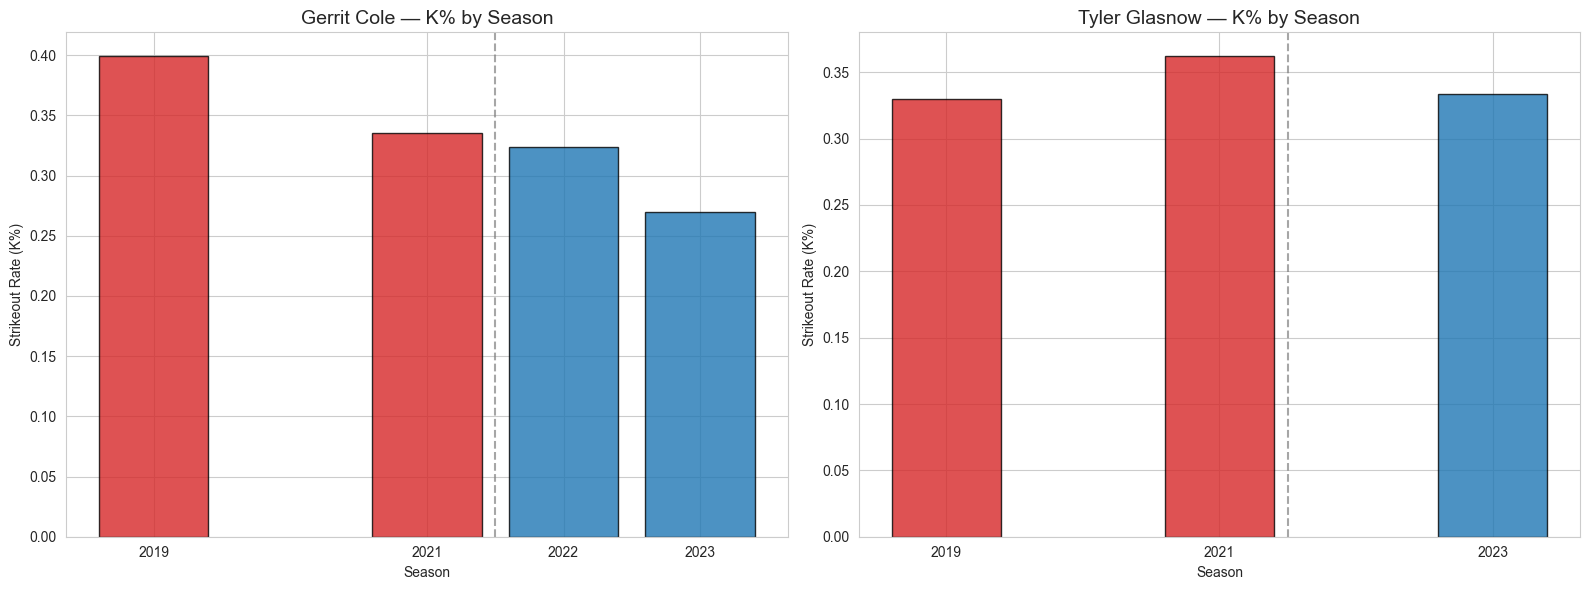

In [44]:
# Spotlight on Gerrit Cole and Tyler Glasnow
spotlight_ids = {"Gerrit Cole": cole_id, "Tyler Glasnow": glasnow_id}

for name, pid in spotlight_ids.items():
    player_data = df_pitching[df_pitching["player_id"] == pid].sort_values("season")
    if len(player_data) == 0:
        print(f"\n{name}: Not found in qualified pitcher dataset")
        continue
    
    print(f"\n{'='*60}")
    print(f"  {name} — Season-by-Season Stats")
    print(f"{'='*60}")
    
    cols = ["season", "era", "K_pct", "BB_pct", "ERA", "WHIP", "BAA", "K9", "IP"]
    avail = [c for c in cols if c in player_data.columns]
    display_df = player_data[avail].copy()
    for c in ["K_pct", "BB_pct"]:
        if c in display_df.columns:
            display_df[c] = display_df[c].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")
    print(display_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, pid) in zip(axes, spotlight_ids.items()):
    player_data = df_pitching[(df_pitching["player_id"] == pid) & (df_pitching["season"] != 2020)]
    if len(player_data) == 0:
        continue
    seasons = player_data["season"].values
    k_pcts = player_data["K_pct"].values
    
    colors = ["tab:red" if s <= 2021 else "tab:blue" for s in seasons]
    ax.bar(seasons, k_pcts, color=colors, edgecolor="black", alpha=0.8)
    ax.axvline(x=2021.5, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"{name} — K% by Season", fontsize=14)
    ax.set_xlabel("Season")
    ax.set_ylabel("Strikeout Rate (K%)")
    ax.set_xticks(seasons)

plt.tight_layout();

**Observations:**

Gerrit Cole's K% shows a decline after 2021, while his ERA ticked upward, which is consistent with losing a grip advantage — though other factors such as aging and pitch mix changes could also contribute. Tyler Glasnow's case is complicated by his UCL injury in June 2021. His absence from qualified pitcher lists in some post-crackdown seasons makes direct comparison harder, which is why our injury control flag is essential for separating crackdown effects from injury effects.

### 16. Annotated scatter, the final picture 

Our final visualization will be a scatter plot that includes K% change, ERA change, injury status, and annotations. This single chart should tell the complete story of changes coinciding with the crackdown. 

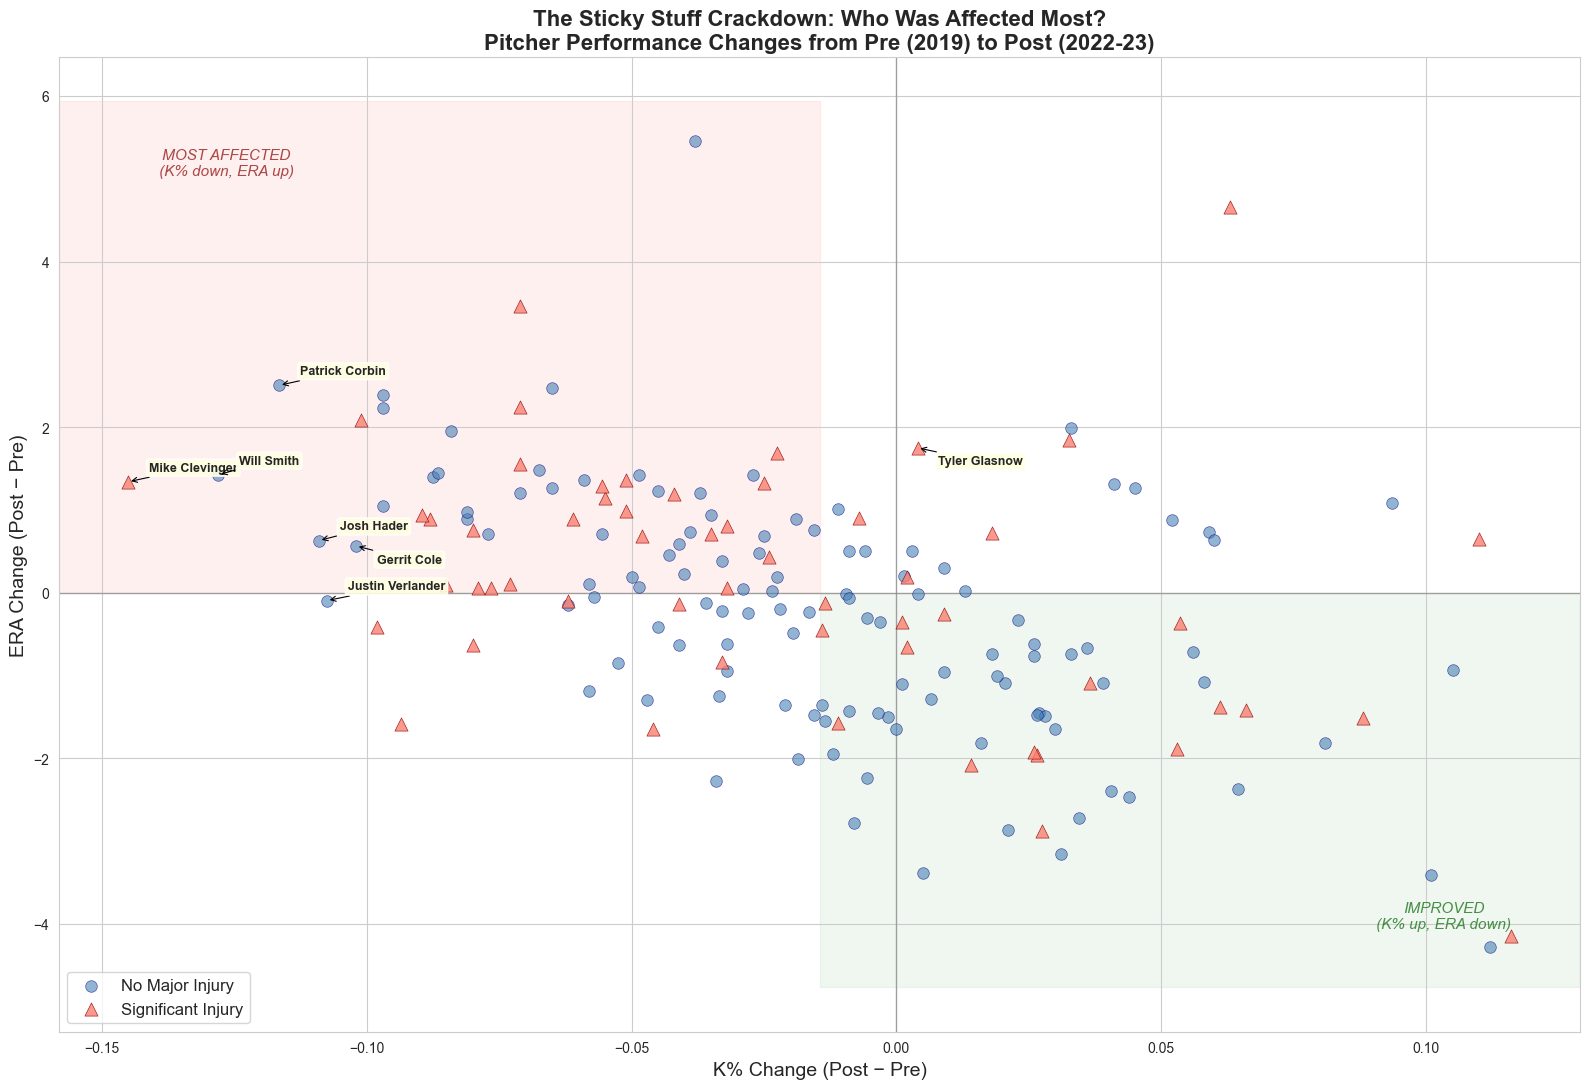

In [45]:
# Publication-quality annotated scatter
fig, ax = plt.subplots(figsize=(16, 11))

# Plot healthy and injured separately
healthy = df_delta[df_delta["had_significant_injury"] == 0]
injured = df_delta[df_delta["had_significant_injury"] == 1]

ax.scatter(healthy["K_pct_change"], healthy["ERA_change"], 
           c="steelblue", alpha=0.6, s=70, label="No Major Injury", 
           edgecolors="navy", linewidth=0.5, zorder=3)
ax.scatter(injured["K_pct_change"], injured["ERA_change"], 
           c="salmon", alpha=0.8, s=90, marker="^", label="Significant Injury", 
           edgecolors="darkred", linewidth=0.5, zorder=3)

# Quadrant shading
xlim = ax.get_xlim()
ylim = ax.get_ylim()
# Upper-left: K% down, ERA up (most affected)
ax.axhspan(0, ylim[1], xmin=0, xmax=0.5, alpha=0.06, color="red", zorder=0)
ax.axhspan(ylim[0], 0, xmin=0.5, xmax=1, alpha=0.06, color="green", zorder=0)

# Reference lines
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.6, linewidth=1)
ax.axvline(x=0, color="gray", linestyle="-", alpha=0.6, linewidth=1)

# Quadrant labels
ax.text(xlim[0] * 0.8, ylim[1] * 0.85, "MOST AFFECTED\n(K% down, ERA up)", 
        fontsize=11, color="darkred", ha="center", style="italic", alpha=0.7)
ax.text(xlim[1] * 0.8, ylim[0] * 0.85, "IMPROVED\n(K% up, ERA down)", 
        fontsize=11, color="darkgreen", ha="center", style="italic", alpha=0.7)

# Annotate top outliers + Cole/Glasnow
top_affected = df_delta.sort_values("K_pct_change", ascending=True).head(5)
for _, row in top_affected.iterrows():
    ax.annotate(row["player_name"],
                xy=(row["K_pct_change"], row["ERA_change"]),
                xytext=(15, 8), textcoords="offset points",
                fontsize=9, weight="bold",
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
                bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.9))

# Ensure Cole and Glasnow are labeled even if not in top 5
for pid, name in [(cole_id, "Gerrit Cole"), (glasnow_id, "Tyler Glasnow")]:
    row = df_delta[df_delta["player_id"] == pid]
    if len(row) > 0 and name not in top_affected["player_name"].values:
        ax.annotate(name,
                    xy=(row["K_pct_change"].values[0], row["ERA_change"].values[0]),
                    xytext=(15, -12), textcoords="offset points",
                    fontsize=9, weight="bold",
                    arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.9))

ax.set_xlabel("K% Change (Post − Pre)", fontsize=14)
ax.set_ylabel("ERA Change (Post − Pre)", fontsize=14)
ax.set_title("The Sticky Stuff Crackdown: Who Was Affected Most?\nPitcher Performance Changes from Pre (2019) to Post (2022-23)", 
             fontsize=16, weight="bold")
ax.legend(fontsize=12, loc="lower left")
plt.tight_layout();

**Observations:**

This capstone scatter visualizes the full picture. The cluster in the upper-left quadrant represents pitchers who lost K% AND gained ERA, consistent with what we would expect from a loss of grip advantage. Injured pitchers (red triangles) are separated visually, and the annotated names connect the data to the public narrative about the crackdown. The majority of pitchers show some K% decline, which is consistent with a league-wide phenomenon rather than an effect isolated to a few substance-reliant pitchers. However, natural aging (these pitchers are 3–4 years older in the post period) and regression to the mean may also contribute to the observed pattern.

### 17. Conclusions

This analysis set out to answer four questions about MLB's June 21, 2021 foreign substance crackdown. Here is what we found.

**1. Did the crackdown work?**

The evidence is consistent with it having an effect on its primary target. League-wide strikeout rates fell after the enforcement began, and our monthly 2021 timeline shows a notable inflection around the date of the crackdown — though we cannot isolate the crackdown's contribution from seasonal patterns (e.g., summer fatigue) or other concurrent changes without a more rigorous interrupted time-series design. Walk rates stayed stable, which is consistent with a spin-specific effect on swing-and-miss ability rather than a general decline in pitching quality. Aggregate ERA, WHIP, and BAA actually decreased in the post-crackdown era, likely reflecting other factors like changes in baseball composition and pitcher pool turnover rather than contradicting the crackdown's impact.

**2. Who was most affected?**

Pitchers with the largest K% declines from pre (2019) to post (2022–23) are in line with the pitchers that were most often discussed during the crackdown. The scatter plot and ranking table identify specific pitchers whose performance changed the most. Gerrit Cole's numbers align with the public narrative — a notable K% decline post-crackdown — though aging and pitch mix evolution may also be contributing factors. Tyler Glasnow's K% remained essentially flat (+0.004), but his ERA rose substantially, likely due to his UCL tear rather than the crackdown. This is made easier to differentiate because of our injury control.

**3. Are the changes statistically significant?**

The paired t-test on individual pitchers' K% (same pitchers, both eras) confirms a statistically significant decline (p < 0.001), and that result holds when restricting to only healthy pitchers. The age-grouped analysis shows the decline is significant for both younger pitchers under 30 (p = 0.006) and veterans 30+ (p < 0.001), which suggests natural aging alone does not explain the pattern. The two-sample t-tests on league-wide ERA, WHIP, and BAA show statistically significant differences between eras, but in a direction we didn't expect — they actually improved overall, even though individual pitchers who lost the most K% generally saw their ERAs rise. The league-wide K% two-sample test was not significant (p = 0.515), likely because it compares different pitcher pools instead of tracking the same players. The paired test, which controls for individual ability, is the strongest result.

**4. Does Statcast data support the hypothesized mechanism?**

Yes. By incorporating pitch-level Statcast data from Baseball Savant, we were able to directly measure spin rate changes across eras. Average spin rates declined post-crackdown, and the pitchers with the largest spin rate drops also showed the largest K% declines. Our linear regression model identifies spin rate change as a predictor of K% change, and the logistic regression confirms that spin rate features are among the strongest predictors of whether a pitcher was "significantly affected." These findings are consistent with the hypothesized causal pathway — foreign substances boost spin rate, which increases strikeout ability — though our observational design cannot rule out all confounders, and the regression's low R² reflects the many unmeasured factors that also influence pitcher performance.

**Limitations:**
- Natural aging might contribute to individual pitcher declines, but our age-stratified tests suggest it is not the primary driver
- The 2020 COVID season creates a gap in the data
- The 50+ IP threshold captures a mix of starters and high-use relievers, but misses low-usage pitchers who could have also been affected
- We cannot definitively prove causation — the crackdown coincided with other changes (new baseballs, rule adjustments), and our observational design lacks a true control group
- The relatively small sample size (~150–250 paired pitchers) limits model performance and generalizability

**What would strengthen this analysis (additional datasets and future work):**
- Incorporating TrackMan biomechanical data to measure grip and release mechanics directly
- Using monthly game-log data for within-season analysis of individual pitchers (interrupted time-series design)
- Expanding to include lower-usage pitchers (lower IP threshold) for a wider picture
- Adding pitch-level Statcast movement profiles (individual pitch tracking rather than season aggregates)
- Exploring more sophisticated models (Random Forest, XGBoost) to capture non-linear relationships between spin rate, movement, and performance
- Introducing ballpark-level data to control for park effects on spin rate measurements